# Analisis Perilaku Simpanan Deposito BPR di Indonesia sebagai Indikasi Risiko Flight to Quality Menggunakan Pendekatan Data Science

## Topik
Stabilitas Sistem Keuangan

## Subtopik
Risiko flight to quality dana pihak ketiga dan dampaknya terhadap stabilitas sistem perbankan

## Latar Awal Proyek
Simpanan deposito merupakan salah satu sumber dana penting bagi Bank Perekonomian Rakyat atau BPR. Jika dana simpanan terlalu terkonsentrasi pada tipe deposan tertentu atau bergerak sangat fluktuatif, maka BPR dapat menghadapi risiko stabilitas pendanaan.

Proyek ini menganalisis perilaku simpanan deposito BPR di Indonesia berdasarkan tipe deposan. Analisis dilakukan untuk melihat tren simpanan, kontribusi tiap tipe deposan, volatilitas simpanan, dan potensi prediksi total simpanan menggunakan pendekatan data science.

## Batas Klaim Penelitian
Penelitian ini tidak bertujuan membuktikan terjadinya flight to quality secara kausal. Penelitian ini hanya membaca indikasi awal risiko dari pola simpanan, konsentrasi dana, volatilitas, dan perbedaan perilaku antar tipe deposan.

## Tujuan
Penelitian ini bertujuan untuk:
1. Menganalisis tren simpanan deposito BPR selama periode 2021 sampai 2024.
2. Membandingkan pola simpanan berdasarkan tipe deposan BPR, Corporate, HNWI, dan Retail.
3. Mengukur kontribusi dan volatilitas simpanan dari setiap tipe deposan.
4. Membuat fitur data science seperti pertumbuhan deposit, lag deposit, rolling mean, dan rolling standard deviation.
5. Membandingkan beberapa model prediksi total deposit secara eksperimental.
6. Menyusun interpretasi dan rekomendasi kebijakan yang mudah dipahami.

In [ ]:
# Import library utama
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Library untuk statistik
from scipy.stats import kruskal

# Library untuk model prediksi
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Menghilangkan warning agar output lebih rapi
import warnings
warnings.filterwarnings("ignore")

## Import Library

Pada tahap ini, beberapa library Python digunakan untuk membaca data, mengolah data, membuat visualisasi, melakukan uji statistik, dan membangun model prediksi.

Library `pandas` dan `numpy` digunakan untuk pengolahan data. Library `matplotlib` digunakan untuk visualisasi. Library `scipy` digunakan untuk uji statistik Kruskal-Wallis. Library `sklearn` digunakan untuk membangun dan mengevaluasi model prediksi.

In [ ]:
from google.colab import files
import zipfile
import os

In [ ]:
uploaded = files.upload()

Saving Dataset Total Deposit in Indonesia.xlsx to Dataset Total Deposit in Indonesia.xlsx


In [ ]:
import os

os.listdir()

['.config', 'Dataset Total Deposit in Indonesia.xlsx', 'sample_data']

In [ ]:
file_path = "Dataset Total Deposit in Indonesia.xlsx"

excel_file = pd.ExcelFile(file_path)
excel_file.sheet_names

['Trend deposit', 'Type depositor', 'Registered User & Deposan']

## Membaca Struktur Dataset

File dataset berhasil diunggah ke Google Colab dalam format Excel. Tahap ini dilakukan untuk melihat daftar sheet yang tersedia di dalam file. Pemeriksaan ini penting karena setiap sheet memiliki fungsi analisis yang berbeda.

Sheet utama yang akan digunakan dalam penelitian adalah sheet yang memuat data simpanan berdasarkan tipe deposan. Sheet lain digunakan sebagai data pendukung untuk melihat tren total deposit, tingkat bunga deposito, dan profil deposan.

In [ ]:
trend_deposit = pd.read_excel(file_path, sheet_name="Trend deposit")
type_depositor = pd.read_excel(file_path, sheet_name="Type depositor")
registered_user = pd.read_excel(file_path, sheet_name="Registered User & Deposan")

In [ ]:
print("Shape Trend Deposit:", trend_deposit.shape)
print("Shape Type Depositor:", type_depositor.shape)
print("Shape Registered User & Deposan:", registered_user.shape)

Shape Trend Deposit: (165, 4)
Shape Type Depositor: (611, 18)
Shape Registered User & Deposan: (572, 7)


In [ ]:
trend_deposit.head()

,All Time Trend Deposit,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,Week-,Period,Total Deposit (IDR),Deposit Rates (%)
3,W2,2021-08-09 00:00:00,10000000,6.5
4,W3,2021-08-16 00:00:00,325500000,6.5


In [ ]:
type_depositor.head()

,Trend Deposit by Type of Depositor,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Breakdown by Depositor Type,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Week,Month,Period,Type depositor,NaN,NaN,NaN,Total (IDR)
2,Period,Week-,Month,Type_Depositor,Total (IDR),%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BPR,Corporate,HNWI,Retail,NaN
3,2021-08-09 00:00:00,W2,August,Retail,10000000,100%,NaN,Description:,NaN,NaN,W2,August,2021-08-09 00:00:00,0,0,0,10000000,10000000
4,2021-08-16 00:00:00,W3,August,HNWI,105500000,32.41%,NaN,BPR,: Rural Banks,NaN,W3,August,2021-08-16 00:00:00,0,0,105500000,220000000,325500000


In [ ]:
registered_user.head()

,Trend New Registered User,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Registered Deposan Breakdown by Age,Unnamed: 6
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Week-,Period,Status,Count,NaN,Age,Number of Depositors
2,W2,2021-08-09 00:00:00,New Registered,12,NaN,<25,18041
3,W2,2021-08-09 00:00:00,New Active,12,NaN,>45th,11659
4,W3,2021-08-16 00:00:00,New Registered,31,NaN,26-45th,66099


## Sumber Ilmiah Dataset

Dataset yang digunakan dalam proyek ini adalah *Dataset for deposit rural banks in Indonesia*. Dataset ini didukung oleh artikel *Data in Brief* tahun 2025 dengan judul *Dataset for deposit rural banks in Indonesia: A trend analysis from 2021 to 2024*.

Artikel pendukung menjelaskan bahwa dataset berasal dari financial reports dan official banking disclosures melalui backend PT Komunal, khususnya depositobpr.id. Dataset mencakup periode 9 Agustus 2021 sampai 26 Agustus 2024, dengan observasi mingguan dan empat tipe deposan, yaitu BPR, Corporate, HNWI, dan Retail.

Dataset ini relevan untuk proyek karena dapat digunakan untuk menganalisis tren perilaku deposan, konsentrasi pendanaan, volatilitas simpanan, dan indikasi awal risiko stabilitas pendanaan BPR.

## Batasan Dataset

Dataset ini bersifat agregat dan tidak memuat data perpindahan dana antarbank secara langsung. Dataset juga tidak memuat indikator kesehatan bank seperti NPL, LDR, CAR, atau tingkat bunga penjaminan LPS.

Karena itu, penelitian ini tidak digunakan untuk membuktikan terjadinya flight to quality secara kausal. Analisis hanya digunakan untuk membaca indikasi awal risiko dari pola simpanan, konsentrasi dana, volatilitas, dan perbedaan perilaku antar tipe deposan.

## Fokus Analisis pada Sheet Type depositor

File Excel yang digunakan memiliki tiga sheet, yaitu `Trend deposit`, `Type depositor`, dan `Registered User & Deposan`. Dalam proyek ini, analisis utama difokuskan pada sheet `Type depositor` karena sheet tersebut memuat informasi yang paling sesuai dengan tujuan penelitian, yaitu periode, tipe deposan, nilai total deposit, dan persentase kontribusi setiap tipe deposan.

Sheet `Trend deposit` digunakan sebagai informasi pendukung untuk memahami struktur umum dataset, sedangkan sheet `Registered User & Deposan` tidak dijadikan fokus utama karena penelitian ini tidak diarahkan pada profil pengguna, tetapi pada perilaku simpanan deposito berdasarkan tipe deposan.

Dengan fokus ini, analisis dapat diarahkan secara lebih konsisten pada tren deposit, kontribusi deposan, volatilitas, konsentrasi dana, uji statistik antar tipe deposan, dan prediksi total deposit.

## Preprocessing Awal: Merapikan Struktur Sheet

Hasil pemeriksaan awal menunjukkan bahwa file Excel memiliki baris judul, baris kosong, dan tabel tambahan di sisi kanan. Oleh karena itu, tahap preprocessing awal dilakukan untuk mengambil bagian data utama, merapikan nama kolom, mengubah tipe data, dan memastikan data siap dianalisis.

Pada tahap ini tidak dilakukan pengisian nilai dengan angka tebakan. Proses yang dilakukan hanya merapikan struktur data agar sesuai dengan kebutuhan analisis.

In [ ]:
# Membersihkan sheet Type depositor
type_clean = type_depositor.iloc[3:, 0:6].copy()

# Mengambil nama kolom dari baris header yang benar
type_clean.columns = type_depositor.iloc[2, 0:6].tolist()

# Mengganti nama kolom agar lebih mudah dipakai
type_clean = type_clean.rename(columns={
    "Week-": "Week",
    "Total (IDR)": "Total_Deposit",
    "%": "Percentage"
})

# Mengubah tipe data
type_clean["Period"] = pd.to_datetime(type_clean["Period"], errors="coerce")
type_clean["Total_Deposit"] = pd.to_numeric(type_clean["Total_Deposit"], errors="coerce")

# Membersihkan kolom persentase
type_clean["Percentage"] = (
    type_clean["Percentage"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .replace("nan", np.nan)
)

type_clean["Percentage"] = pd.to_numeric(type_clean["Percentage"], errors="coerce")

# Menghapus baris kosong pada kolom utama
type_clean = type_clean.dropna(
    subset=["Period", "Week", "Month", "Type_Depositor", "Total_Deposit"]
).reset_index(drop=True)

type_clean.head()

,Period,Week,Month,Type_Depositor,Total_Deposit,Percentage
0,2021-08-09,W2,August,Retail,10000000,100.00
1,2021-08-16,W3,August,HNWI,105500000,32.41
2,2021-08-16,W3,August,Retail,220000000,67.59
3,2021-08-23,W4,August,HNWI,148400000,46.35
4,2021-08-23,W4,August,Retail,171800000,53.65


In [ ]:
print("Shape data setelah dibersihkan:", type_clean.shape)
print("Periode awal:", type_clean["Period"].min())
print("Periode akhir:", type_clean["Period"].max())

type_clean.info()

Shape data setelah dibersihkan: (608, 6)
Periode awal: 2021-08-09 00:00:00
Periode akhir: 2024-08-26 00:00:00
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608 entries, 0 to 607
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Period          608 non-null    datetime64[ns]
 1   Week            608 non-null    object        
 2   Month           608 non-null    object        
 3   Type_Depositor  608 non-null    object        
 4   Total_Deposit   608 non-null    int64         
 5   Percentage      608 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 28.6+ KB


In [ ]:
type_clean["Type_Depositor"].value_counts()

,count
Type_Depositor,
Retail,159
HNWI,158
BPR,147
Corporate,144


## Interpretasi Preprocessing Awal

Hasil preprocessing awal menunjukkan bahwa sheet `Type depositor` berhasil dibersihkan menjadi 608 baris dan 6 kolom. Periode data dimulai dari 9 Agustus 2021 sampai 26 Agustus 2024. Kolom `Period` sudah berubah menjadi format tanggal, kolom `Total_Deposit` sudah berubah menjadi numerik, dan kolom `Percentage` sudah berubah menjadi numerik.

Dataset bersih ini memuat empat tipe deposan, yaitu Retail, HNWI, BPR, dan Corporate. Sheet ini akan digunakan sebagai dataset utama karena memuat informasi simpanan deposito berdasarkan periode, minggu, bulan, tipe deposan, total deposit, dan persentase kontribusi.

## Audit Kualitas Data

Setelah data utama berhasil dirapikan, tahap berikutnya adalah melakukan audit kualitas data. Audit ini dilakukan untuk memastikan tidak ada missing value, duplikasi, kesalahan kategori deposan, atau ketidakwajaran nilai pada variabel utama.

Tahap ini penting karena hasil visualisasi, uji statistik, dan model prediksi hanya dapat dipercaya jika data dasar yang digunakan sudah konsisten.

In [ ]:
# Audit missing value
type_clean.isna().sum()

,0
Period,0
Week,0
Month,0
Type_Depositor,0
Total_Deposit,0
Percentage,0


In [ ]:
# Audit duplikasi seluruh baris
type_clean.duplicated().sum()

np.int64(0)

In [ ]:
# Audit duplikasi berdasarkan kombinasi periode dan tipe deposan
type_clean.duplicated(subset=["Period", "Week", "Month", "Type_Depositor"]).sum()

np.int64(0)

In [ ]:
# Audit kategori tipe deposan
type_clean["Type_Depositor"].value_counts()

,count
Type_Depositor,
Retail,159
HNWI,158
BPR,147
Corporate,144


In [ ]:
# Statistik deskriptif variabel numerik
type_clean[["Total_Deposit", "Percentage"]].describe()

,Total_Deposit,Percentage
count,6.080000e+02,608.000000
mean,2.121314e+10,26.151053
std,2.431117e+10,22.071058
min,1.000000e+06,0.020000
25%,3.391250e+09,6.657500
50%,1.086325e+10,20.910000
75%,3.111250e+10,43.205000
max,1.396500e+11,100.000000


In [ ]:
# Audit total persentase per periode
percentage_check = (
    type_clean
    .groupby("Period")["Percentage"]
    .sum()
    .reset_index()
)

percentage_check.describe()

,Period,Percentage
count,159,159.000000
mean,2023-02-19 06:02:15.849056512,99.998994
min,2021-08-09 00:00:00,99.990000
25%,2022-05-19 12:00:00,100.000000
50%,2023-02-20 00:00:00,100.000000
75%,2023-11-23 12:00:00,100.000000
max,2024-08-26 00:00:00,100.010000
std,NaN,0.005974


## Interpretasi Audit Kualitas Data

Hasil audit kualitas data menunjukkan bahwa dataset utama tidak memiliki missing value dan tidak memiliki duplikasi. Kolom utama seperti `Period`, `Week`, `Month`, `Type_Depositor`, `Total_Deposit`, dan `Percentage` sudah lengkap.

Dataset juga memiliki empat tipe deposan, yaitu Retail, HNWI, BPR, dan Corporate. Jumlah observasi setiap tipe deposan tidak sama persis karena pada beberapa periode awal tidak semua tipe deposan tercatat. Kondisi ini tidak dianggap sebagai kesalahan karena data tetap merepresentasikan observasi aktual pada setiap periode.

Total persentase kontribusi deposan per periode berada di sekitar 100%. Nilai minimum 99.99 dan maksimum 100.01 menunjukkan adanya selisih kecil akibat pembulatan angka persentase. Dengan demikian, dataset dinilai konsisten dan layak digunakan untuk tahap visualisasi serta analisis lanjutan.

## Visualisasi 1: Tren Total Deposit dari Waktu ke Waktu

Pada tahap ini, total deposit dihitung berdasarkan periode waktu. Karena data utama masih berbentuk per tipe deposan, nilai `Total_Deposit` dijumlahkan terlebih dahulu untuk setiap `Period`.

Visualisasi ini digunakan untuk melihat pola umum simpanan deposito BPR dari waktu ke waktu. Grafik ini membantu melihat apakah total deposit cenderung meningkat, menurun, atau berfluktuasi selama periode 2021 sampai 2024.

In [ ]:
# Menghitung total deposit per periode
total_deposit_trend = (
    type_clean
    .groupby("Period")["Total_Deposit"]
    .sum()
    .reset_index()
)

total_deposit_trend.head()

,Period,Total_Deposit
0,2021-08-09,10000000
1,2021-08-16,325500000
2,2021-08-23,320200000
3,2021-08-30,709900000
4,2021-09-06,384500000


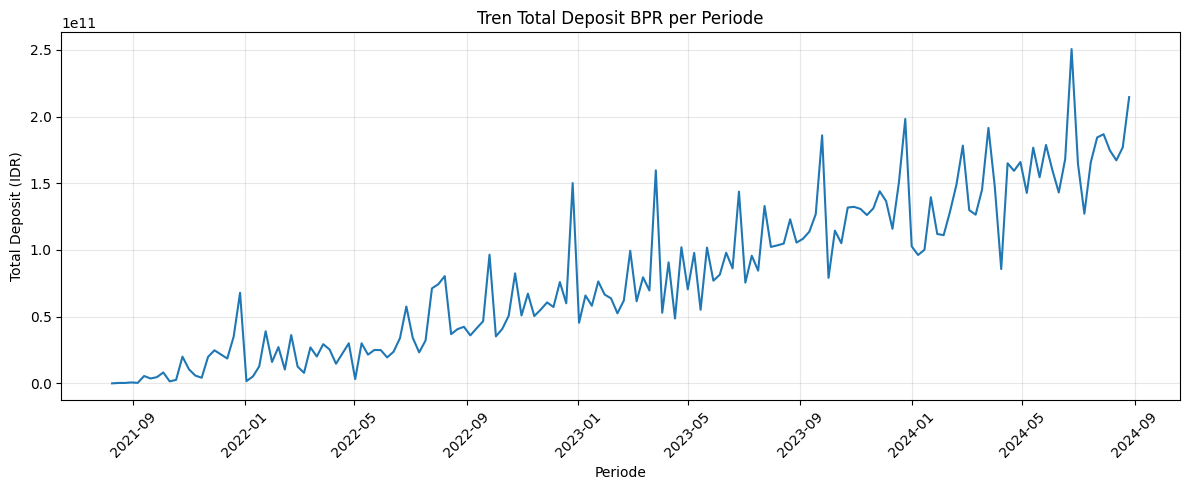

In [ ]:
# Visualisasi tren total deposit
plt.figure(figsize=(12, 5))
plt.plot(total_deposit_trend["Period"], total_deposit_trend["Total_Deposit"])

plt.title("Tren Total Deposit BPR per Periode")
plt.xlabel("Periode")
plt.ylabel("Total Deposit (IDR)")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
total_deposit_trend["Total_Deposit"].describe()

,Total_Deposit
count,1.590000e+02
mean,8.111693e+10
std,5.801114e+10
min,1.000000e+07
25%,3.003120e+10
50%,7.433740e+10
75%,1.280164e+11
max,2.505617e+11


## Interpretasi Visualisasi Tren Total Deposit

Grafik tren total deposit menunjukkan bahwa simpanan deposito BPR dalam dataset cenderung meningkat selama periode 2021 sampai 2024. Pada awal periode, nilai total deposit masih relatif kecil. Seiring waktu, nilai total deposit meningkat dan beberapa kali mencapai nilai yang jauh lebih tinggi.

Namun, tren tersebut tidak bergerak secara stabil. Terdapat beberapa lonjakan dan penurunan tajam pada periode tertentu. Pola ini menunjukkan bahwa simpanan deposito BPR memiliki fluktuasi yang cukup besar dari waktu ke waktu.

Berdasarkan statistik deskriptif, rata-rata total deposit per periode adalah sekitar Rp81,12 miliar. Nilai minimum tercatat sebesar Rp10 juta, sedangkan nilai maksimum mencapai sekitar Rp250,56 miliar. Perbedaan yang besar antara nilai minimum dan maksimum menunjukkan adanya variasi simpanan yang tinggi.

Temuan awal ini mendukung perlunya analisis lanjutan berdasarkan tipe deposan. Analisis per tipe deposan diperlukan untuk mengetahui kelompok deposan mana yang paling berkontribusi terhadap kenaikan total deposit dan kelompok mana yang paling berfluktuasi.

## Visualisasi 2: Tren Total Deposit Berdasarkan Tipe Deposan

Visualisasi berikutnya digunakan untuk membandingkan pola simpanan antar tipe deposan, yaitu BPR, Corporate, HNWI, dan Retail. Analisis ini penting karena total deposit yang meningkat belum tentu berasal dari semua tipe deposan secara merata.

Dengan melihat tren per tipe deposan, kita dapat mengetahui tipe deposan mana yang memiliki kontribusi besar dan tipe mana yang lebih berfluktuasi.

In [ ]:
# Membuat pivot tren deposit berdasarkan tipe deposan
deposit_by_type = (
    type_clean
    .pivot_table(
        index="Period",
        columns="Type_Depositor",
        values="Total_Deposit",
        aggfunc="sum"
    )
    .reset_index()
)

deposit_by_type.head()

Type_Depositor,Period,BPR,Corporate,HNWI,Retail
0,2021-08-09,NaN,NaN,NaN,10000000.0
1,2021-08-16,NaN,NaN,105500000.0,220000000.0
2,2021-08-23,NaN,NaN,148400000.0,171800000.0
3,2021-08-30,11000000.0,55000000.0,196500000.0,447400000.0
4,2021-09-06,1000000.0,NaN,162500000.0,221000000.0


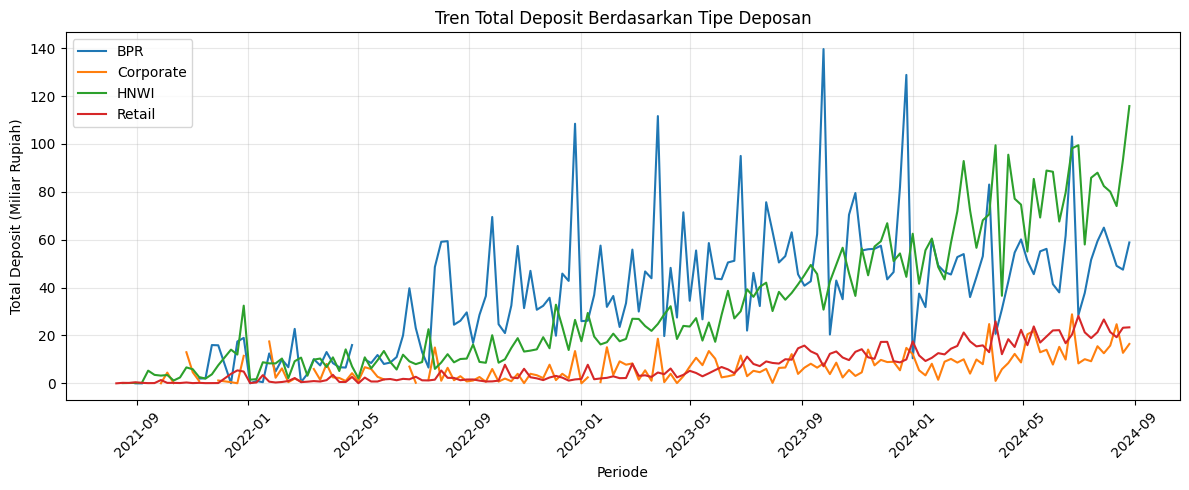

In [ ]:
# Membuat salinan data dalam satuan miliar rupiah
deposit_by_type_billion = deposit_by_type.copy()

for depositor in ["BPR", "Corporate", "HNWI", "Retail"]:
    if depositor in deposit_by_type_billion.columns:
        deposit_by_type_billion[depositor] = deposit_by_type_billion[depositor] / 1_000_000_000

plt.figure(figsize=(12, 5))

for depositor in ["BPR", "Corporate", "HNWI", "Retail"]:
    if depositor in deposit_by_type_billion.columns:
        plt.plot(
            deposit_by_type_billion["Period"],
            deposit_by_type_billion[depositor],
            label=depositor
        )

plt.title("Tren Total Deposit Berdasarkan Tipe Deposan")
plt.xlabel("Periode")
plt.ylabel("Total Deposit (Miliar Rupiah)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Interpretasi Visualisasi Tren Deposit Berdasarkan Tipe Deposan

Grafik menunjukkan bahwa nilai simpanan deposito tidak tersebar merata pada semua tipe deposan. Kelompok BPR dan HNWI memiliki nilai simpanan yang jauh lebih besar dibanding Corporate dan Retail.

Kelompok BPR memiliki beberapa lonjakan besar, bahkan sempat mencapai sekitar Rp140 miliar pada periode tertentu. Hal ini menunjukkan bahwa BPR menjadi salah satu kelompok deposan dengan kontribusi besar, tetapi juga memiliki pola yang cukup fluktuatif.

Kelompok HNWI menunjukkan tren peningkatan yang kuat, terutama pada tahun 2024. Nilainya bahkan mendekati dan beberapa kali melampaui kelompok BPR pada akhir periode pengamatan. Kondisi ini menunjukkan bahwa deposan bernilai tinggi memiliki peran penting dalam pembentukan total simpanan.

Corporate dan Retail cenderung memiliki nilai simpanan yang lebih rendah. Walaupun tetap mengalami perubahan dari waktu ke waktu, fluktuasinya tidak sebesar BPR dan HNWI.

Secara awal, grafik ini menunjukkan adanya potensi risiko konsentrasi pendanaan. Jika sebagian besar dana deposito bergantung pada tipe deposan besar seperti BPR dan HNWI, maka perubahan perilaku pada kelompok tersebut dapat memengaruhi stabilitas pendanaan BPR.

## Visualisasi 3: Kontribusi Total Deposit Berdasarkan Tipe Deposan

Visualisasi ini digunakan untuk melihat kontribusi akumulatif setiap tipe deposan terhadap total simpanan deposito selama periode penelitian. Analisis ini membantu mengetahui apakah sumber dana deposito terkonsentrasi pada kelompok deposan tertentu.

In [ ]:
# Menghitung total deposit berdasarkan tipe deposan
deposit_contribution = (
    type_clean
    .groupby("Type_Depositor")["Total_Deposit"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Mengubah ke miliar rupiah agar lebih mudah dibaca
deposit_contribution["Total_Deposit_Billion"] = deposit_contribution["Total_Deposit"] / 1_000_000_000

deposit_contribution

,Type_Depositor,Total_Deposit,Total_Deposit_Billion
0,BPR,5712972100000,5712.972100
1,HNWI,5083296007693,5083.296008
2,Retail,1154927844611,1154.927845
3,Corporate,946396100000,946.396100


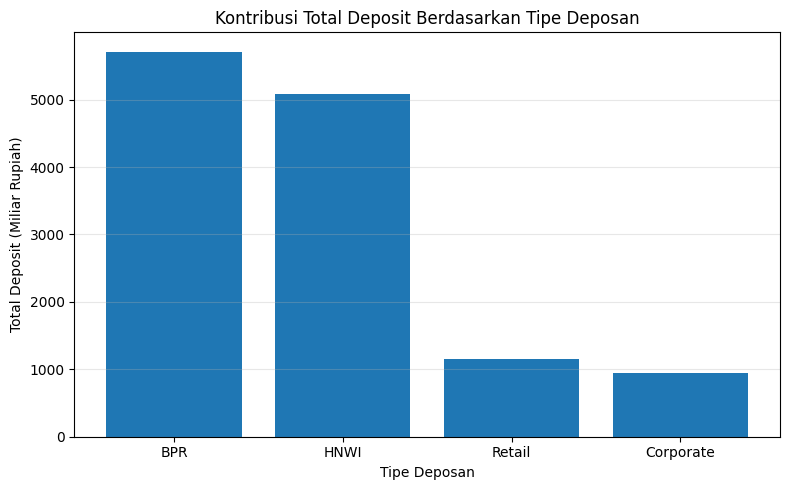

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(
    deposit_contribution["Type_Depositor"],
    deposit_contribution["Total_Deposit_Billion"]
)

plt.title("Kontribusi Total Deposit Berdasarkan Tipe Deposan")
plt.xlabel("Tipe Deposan")
plt.ylabel("Total Deposit (Miliar Rupiah)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Menghitung persentase kontribusi total deposit setiap tipe deposan
total_all_deposit = deposit_contribution["Total_Deposit"].sum()

deposit_contribution["Share_Total_Percent"] = (
    deposit_contribution["Total_Deposit"] / total_all_deposit * 100
)

deposit_contribution

,Type_Depositor,Total_Deposit,Total_Deposit_Billion,Share_Total_Percent
0,BPR,5712972100000,5712.972100,44.294874
1,HNWI,5083296007693,5083.296008,39.412752
2,Retail,1154927844611,1154.927845,8.954601
3,Corporate,946396100000,946.396100,7.337774


## Interpretasi Visualisasi Kontribusi Total Deposit

Grafik kontribusi total deposit menunjukkan bahwa simpanan deposito dalam dataset sangat didominasi oleh dua tipe deposan, yaitu BPR dan HNWI. BPR mencatat total deposit sekitar Rp5.712,97 miliar, sedangkan HNWI mencatat sekitar Rp5.083,30 miliar.

Retail dan Corporate memiliki kontribusi yang jauh lebih kecil. Retail mencatat total deposit sekitar Rp1.154,93 miliar, sedangkan Corporate sekitar Rp946,40 miliar.

Temuan ini menunjukkan adanya konsentrasi sumber dana pada kelompok deposan besar. Jika simpanan deposito terlalu bergantung pada BPR dan HNWI, maka perubahan perilaku dari dua kelompok tersebut dapat memengaruhi stabilitas pendanaan BPR.

Dalam konteks indikasi risiko flight to quality, hasil ini penting karena kelompok deposan besar biasanya memiliki kapasitas lebih tinggi untuk memindahkan dana ketika melihat perubahan risiko, imbal hasil, atau kondisi pasar. Namun, penelitian ini tetap tidak menyimpulkan adanya perpindahan dana secara kausal karena dataset tidak memuat data aliran dana antarbank secara langsung.

## Visualisasi 4: Sebaran Total Deposit Berdasarkan Tipe Deposan

Visualisasi ini digunakan untuk melihat sebaran nilai total deposit pada setiap tipe deposan. Berbeda dengan grafik tren, boxplot membantu melihat median, rentang nilai, dan kemungkinan nilai ekstrem pada masing-masing tipe deposan.

Grafik ini penting karena risiko stabilitas pendanaan tidak hanya dilihat dari besar kecilnya total deposit, tetapi juga dari seberapa fluktuatif nilai simpanan pada setiap tipe deposan.

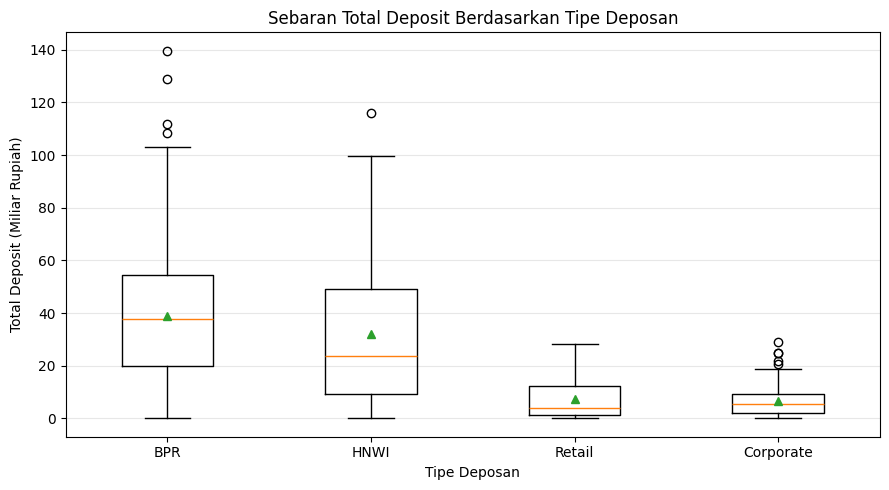

In [ ]:
# Membuat data boxplot dalam satuan miliar rupiah
type_clean_boxplot = type_clean.copy()
type_clean_boxplot["Total_Deposit_Billion"] = type_clean_boxplot["Total_Deposit"] / 1_000_000_000

# Urutan tipe deposan
depositor_order = ["BPR", "HNWI", "Retail", "Corporate"]

boxplot_data = [
    type_clean_boxplot[type_clean_boxplot["Type_Depositor"] == depositor]["Total_Deposit_Billion"]
    for depositor in depositor_order
]

plt.figure(figsize=(9, 5))
plt.boxplot(boxplot_data, labels=depositor_order, showmeans=True)

plt.title("Sebaran Total Deposit Berdasarkan Tipe Deposan")
plt.xlabel("Tipe Deposan")
plt.ylabel("Total Deposit (Miliar Rupiah)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Statistik deskriptif total deposit per tipe deposan
deposit_stats_by_type = (
    type_clean_boxplot
    .groupby("Type_Depositor")["Total_Deposit_Billion"]
    .describe()
    .reset_index()
)

deposit_stats_by_type

,Type_Depositor,count,mean,std,min,25%,50%,75%,max
0,BPR,147.0,38.863756,25.766375,0.0010,19.9500,37.75000,54.33125,139.6500
1,Corporate,144.0,6.572195,5.707475,0.0100,2.0000,5.53000,9.21000,28.8375
2,HNWI,158.0,32.172760,27.876215,0.1055,9.3455,23.70095,49.25365,115.8252
3,Retail,159.0,7.263697,7.371114,0.0100,1.3275,3.84250,12.16945,28.1854


## Interpretasi Visualisasi Sebaran Total Deposit

Boxplot menunjukkan bahwa kelompok BPR dan HNWI memiliki sebaran total deposit yang lebih besar dibanding Retail dan Corporate. Median deposit BPR berada di sekitar Rp37,75 miliar, sedangkan median HNWI berada di sekitar Rp23,70 miliar. Nilai ini jauh lebih tinggi dibanding Retail dan Corporate.

Kelompok BPR memiliki nilai maksimum sekitar Rp139,65 miliar, sedangkan HNWI memiliki nilai maksimum sekitar Rp115,83 miliar. Kedua kelompok ini juga memiliki beberapa nilai ekstrem. Hal ini menunjukkan bahwa simpanan dari BPR dan HNWI tidak hanya besar, tetapi juga bergerak dengan variasi yang tinggi.

Retail dan Corporate memiliki nilai deposit yang lebih rendah. Namun, kedua kelompok ini tetap memiliki variasi nilai dari waktu ke waktu, terutama Retail yang memiliki standar deviasi relatif tinggi dibanding rata-ratanya.

Secara awal, hasil ini menunjukkan bahwa BPR dan HNWI merupakan tipe deposan yang perlu mendapat perhatian khusus. Jika sumber dana terlalu bergantung pada kelompok deposan besar dan fluktuatif, maka stabilitas pendanaan BPR dapat lebih rentan terhadap perubahan perilaku simpanan.

## Pengukuran Volatilitas Relatif dengan Koefisien Variasi

Setelah melihat sebaran total deposit melalui boxplot, tahap berikutnya adalah menghitung koefisien variasi. Koefisien variasi digunakan untuk membandingkan tingkat volatilitas relatif antar tipe deposan.

Nilai koefisien variasi dihitung dari standar deviasi dibagi rata-rata. Semakin tinggi nilainya, semakin besar volatilitas relatif simpanan pada tipe deposan tersebut.

In [ ]:
# Menghitung koefisien variasi setiap tipe deposan
cv_by_type = (
    type_clean_boxplot
    .groupby("Type_Depositor")["Total_Deposit_Billion"]
    .agg(["mean", "std"])
    .reset_index()
)

cv_by_type["Coefficient_of_Variation"] = cv_by_type["std"] / cv_by_type["mean"]

cv_by_type = cv_by_type.sort_values(
    by="Coefficient_of_Variation",
    ascending=False
)

cv_by_type

,Type_Depositor,mean,std,Coefficient_of_Variation
3,Retail,7.263697,7.371114,1.014788
1,Corporate,6.572195,5.707475,0.868427
2,HNWI,32.172760,27.876215,0.866454
0,BPR,38.863756,25.766375,0.662992


## Interpretasi Koefisien Variasi

Hasil perhitungan koefisien variasi menunjukkan bahwa Retail memiliki volatilitas relatif tertinggi dengan nilai sekitar 1,015. Artinya, jika dibandingkan dengan rata-rata simpanannya, simpanan Retail mengalami perubahan relatif yang paling besar.

Corporate dan HNWI memiliki nilai koefisien variasi yang hampir sama, yaitu sekitar 0,868 dan 0,866. Hal ini menunjukkan bahwa kedua kelompok tersebut juga memiliki tingkat variasi yang cukup tinggi.

BPR memiliki koefisien variasi paling rendah dibanding tipe deposan lain, yaitu sekitar 0,663. Namun, BPR tetap menjadi kelompok penting karena memiliki rata-rata simpanan terbesar secara nominal.

Dengan demikian, risiko perlu dibaca dari dua sisi. Dari sisi volatilitas relatif, Retail menunjukkan perubahan paling besar dibanding rata-ratanya. Namun, dari sisi nilai nominal dan konsentrasi dana, BPR dan HNWI tetap menjadi kelompok yang paling perlu dipantau karena menyumbang nilai simpanan terbesar.

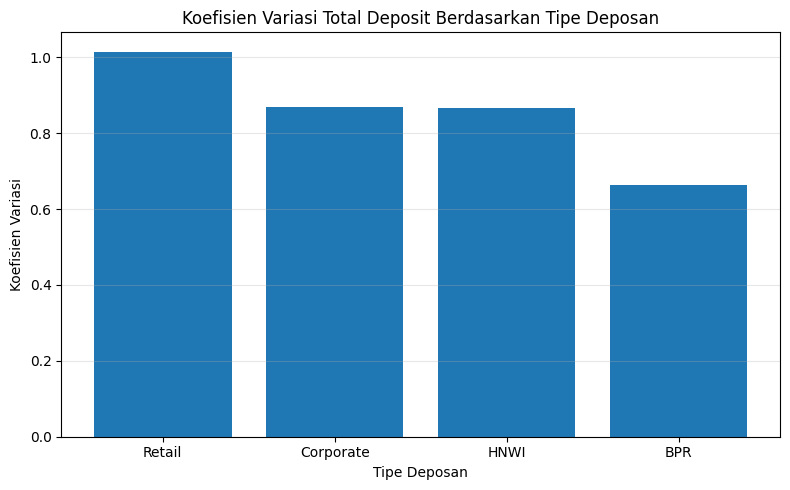

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(
    cv_by_type["Type_Depositor"],
    cv_by_type["Coefficient_of_Variation"]
)

plt.title("Koefisien Variasi Total Deposit Berdasarkan Tipe Deposan")
plt.xlabel("Tipe Deposan")
plt.ylabel("Koefisien Variasi")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Interpretasi Visualisasi Koefisien Variasi

Grafik koefisien variasi menunjukkan bahwa Retail memiliki volatilitas relatif tertinggi. Nilainya berada sedikit di atas 1, yang berarti variasi simpanan Retail lebih besar dibanding rata-rata simpanannya sendiri.

Corporate dan HNWI berada pada tingkat volatilitas relatif yang hampir sama. Keduanya menunjukkan perubahan simpanan yang cukup besar dibanding rata-ratanya.

BPR memiliki koefisien variasi paling rendah dibanding tipe deposan lain. Namun, BPR tetap penting karena nilai simpanannya paling besar secara nominal. Artinya, meskipun volatilitas relatif BPR lebih rendah, perubahan nominal pada kelompok ini tetap dapat berdampak besar terhadap total simpanan.

Hasil ini menunjukkan bahwa analisis risiko perlu dibaca dari dua sudut. Retail memiliki risiko volatilitas relatif tertinggi, sedangkan BPR dan HNWI memiliki risiko konsentrasi nominal yang lebih besar.

## Feature Engineering 1: Pertumbuhan Deposit

Pada tahap ini dibuat fitur baru bernama `deposit_growth`. Fitur ini menunjukkan persentase perubahan nilai deposit dari periode sebelumnya untuk setiap tipe deposan.

Fitur ini penting karena perubahan deposit yang tajam dapat menjadi sinyal awal adanya volatilitas perilaku deposan. Dalam konteks stabilitas pendanaan, penurunan deposit yang besar perlu diperhatikan karena dapat memengaruhi kemampuan BPR dalam menjaga sumber dananya.

In [ ]:
# Membuat salinan data untuk feature engineering
feature_data = type_clean.copy()

# Mengurutkan data berdasarkan tipe deposan dan periode
feature_data = feature_data.sort_values(
    by=["Type_Depositor", "Period"]
).reset_index(drop=True)

# Membuat fitur pertumbuhan deposit per tipe deposan
feature_data["deposit_growth"] = (
    feature_data
    .groupby("Type_Depositor")["Total_Deposit"]
    .pct_change()
)

# Menampilkan hasil awal
feature_data.head(10)

,Period,Week,Month,Type_Depositor,Total_Deposit,Percentage,deposit_growth
0,2021-08-30,W1,August,BPR,11000000,1.55,NaN
1,2021-09-06,W2,September,BPR,1000000,0.26,-0.909091
2,2021-11-08,W2,November,BPR,2000000000,34.26,1999.000000
3,2021-11-15,W3,November,BPR,2100000000,49.97,0.050000
4,2021-11-22,W4,November,BPR,16000000000,80.42,6.619048
5,2021-11-29,W1,November,BPR,15900000000,64.15,-0.006250
6,2021-12-13,W3,December,BPR,75000000,0.40,-0.995283
7,2021-12-20,W4,December,BPR,17500000000,50.00,232.333333
8,2021-12-27,W5,December,BPR,19000000000,27.98,0.085714
9,2022-01-03,W1,January,BPR,10000000,0.60,-0.999474


In [ ]:
# Mengecek missing value setelah membuat deposit_growth
feature_data[["Type_Depositor", "Period", "Total_Deposit", "deposit_growth"]].isna().sum()

,0
Type_Depositor,0
Period,0
Total_Deposit,0
deposit_growth,4


In [ ]:
# Statistik deskriptif deposit_growth berdasarkan tipe deposan
growth_stats = (
    feature_data
    .groupby("Type_Depositor")["deposit_growth"]
    .describe()
    .reset_index()
)

growth_stats

,Type_Depositor,count,mean,std,min,25%,50%,75%,max
0,BPR,146.0,16.400736,166.532188,-0.999474,-0.261075,0.053064,0.570049,1999.000000
1,Corporate,143.0,7.053046,33.364833,-0.999259,-0.589179,0.067308,1.540408,249.000000
2,HNWI,157.0,0.380953,2.616532,-0.952981,-0.206319,0.055870,0.335821,31.707692
3,Retail,158.0,0.867351,4.448779,-0.977847,-0.228480,0.026441,0.410883,39.588235


## Interpretasi Awal Fitur deposit_growth

Fitur `deposit_growth` berhasil dibuat untuk mengukur perubahan nilai deposit dari periode sebelumnya pada setiap tipe deposan. Hasil audit menunjukkan terdapat 4 missing value pada kolom `deposit_growth`. Hal ini normal karena setiap tipe deposan memiliki satu observasi awal yang tidak memiliki data periode sebelumnya.

Hasil statistik deskriptif menunjukkan adanya nilai pertumbuhan yang sangat ekstrem, terutama pada BPR dan Corporate. Nilai maksimum pertumbuhan BPR mencapai 1999, sedangkan Corporate mencapai 249. Nilai ini muncul karena pada beberapa periode nilai deposit sebelumnya sangat kecil, lalu meningkat tajam pada periode berikutnya.

Secara perhitungan, nilai tersebut benar. Namun, secara analisis, fitur `deposit_growth` terlalu sensitif terhadap nilai awal yang sangat kecil. Oleh karena itu, fitur ini tetap berguna untuk membaca perubahan simpanan, tetapi perlu digunakan secara hati-hati dalam visualisasi dan modelling.

Untuk tahap berikutnya, diperlukan fitur pertumbuhan yang lebih stabil agar nilai ekstrem tidak terlalu mendominasi hasil analisis.

## Feature Engineering 2: Log Deposit Growth

Fitur `deposit_growth` menunjukkan perubahan deposit dari periode sebelumnya. Namun, hasil sebelumnya menunjukkan adanya nilai pertumbuhan yang sangat ekstrem. Nilai ekstrem tersebut terjadi karena deposit pada periode sebelumnya sangat kecil, lalu meningkat tajam pada periode berikutnya.

Untuk membuat ukuran pertumbuhan yang lebih stabil, dibuat fitur `log_deposit_growth`. Fitur ini dihitung dari selisih logaritma antara total deposit saat ini dan total deposit pada periode sebelumnya.

Fitur ini tetap berasal dari data asli, bukan dari nilai tebakan. Tujuannya adalah mengurangi dampak nilai ekstrem agar analisis pertumbuhan deposit lebih mudah dibaca.

In [ ]:
# Membuat fitur lag deposit satu periode sebelumnya
feature_data["lag_deposit_1"] = (
    feature_data
    .groupby("Type_Depositor")["Total_Deposit"]
    .shift(1)
)

# Membuat fitur log deposit growth
feature_data["log_deposit_growth"] = (
    np.log(feature_data["Total_Deposit"]) - np.log(feature_data["lag_deposit_1"])
)

# Menampilkan hasil awal
feature_data[
    [
        "Period",
        "Week",
        "Month",
        "Type_Depositor",
        "Total_Deposit",
        "lag_deposit_1",
        "deposit_growth",
        "log_deposit_growth"
    ]
].head(10)

,Period,Week,Month,Type_Depositor,Total_Deposit,lag_deposit_1,deposit_growth,log_deposit_growth
0,2021-08-30,W1,August,BPR,11000000,NaN,NaN,NaN
1,2021-09-06,W2,September,BPR,1000000,1.100000e+07,-0.909091,-2.397895
2,2021-11-08,W2,November,BPR,2000000000,1.000000e+06,1999.000000,7.600902
3,2021-11-15,W3,November,BPR,2100000000,2.000000e+09,0.050000,0.048790
4,2021-11-22,W4,November,BPR,16000000000,2.100000e+09,6.619048,2.030651
5,2021-11-29,W1,November,BPR,15900000000,1.600000e+10,-0.006250,-0.006270
6,2021-12-13,W3,December,BPR,75000000,1.590000e+10,-0.995283,-5.356586
7,2021-12-20,W4,December,BPR,17500000000,7.500000e+07,232.333333,5.452468
8,2021-12-27,W5,December,BPR,19000000000,1.750000e+10,0.085714,0.082238
9,2022-01-03,W1,January,BPR,10000000,1.900000e+10,-0.999474,-7.549609


In [ ]:
# Statistik deskriptif log_deposit_growth berdasarkan tipe deposan
log_growth_stats = (
    feature_data
    .groupby("Type_Depositor")["log_deposit_growth"]
    .describe()
    .reset_index()
)

log_growth_stats

,Type_Depositor,count,mean,std,min,25%,50%,75%,max
0,BPR,146.0,0.058802,1.407772,-7.549609,-0.302563,0.051704,0.451104,7.600902
1,Corporate,143.0,0.039872,1.806066,-7.207860,-0.889699,0.065139,0.931722,5.521461
2,HNWI,157.0,0.044593,0.618955,-3.057214,-0.231074,0.054365,0.289546,3.487610
3,Retail,158.0,0.049102,0.897264,-3.809795,-0.259417,0.026097,0.344150,3.703478


## Interpretasi Fitur log_deposit_growth

Hasil statistik deskriptif menunjukkan bahwa fitur `log_deposit_growth` lebih stabil dibandingkan `deposit_growth`. Pada fitur `deposit_growth`, nilai maksimum pertumbuhan sangat ekstrem karena terdapat periode dengan nilai deposit sebelumnya sangat kecil. Setelah menggunakan pendekatan log, nilai ekstrem menjadi lebih terkendali.

Rata-rata `log_deposit_growth` pada seluruh tipe deposan bernilai positif kecil. Hal ini menunjukkan bahwa secara umum deposit masih memiliki kecenderungan bertumbuh, meskipun pertumbuhannya tidak selalu stabil pada setiap periode.

Corporate memiliki standar deviasi terbesar, yaitu 1,8061, diikuti BPR sebesar 1,4078. Hal ini menunjukkan bahwa perubahan deposit Corporate dan BPR relatif lebih berfluktuasi dibandingkan HNWI dan Retail jika dilihat dari ukuran pertumbuhan berbasis log.

HNWI memiliki standar deviasi paling rendah, yaitu 0,6190. Artinya, dari sisi pertumbuhan berbasis log, HNWI cenderung lebih stabil dibandingkan tipe deposan lainnya. Namun, karena nilai deposit HNWI secara nominal besar, deposan ini tetap penting dalam analisis risiko konsentrasi pendanaan.

## Visualisasi 5: Sebaran Log Deposit Growth Berdasarkan Tipe Deposan

Visualisasi ini digunakan untuk membandingkan sebaran pertumbuhan deposit berbasis log pada setiap tipe deposan. Dengan boxplot, dapat dilihat tipe deposan mana yang memiliki pertumbuhan lebih stabil dan tipe deposan mana yang memiliki fluktuasi lebih besar.

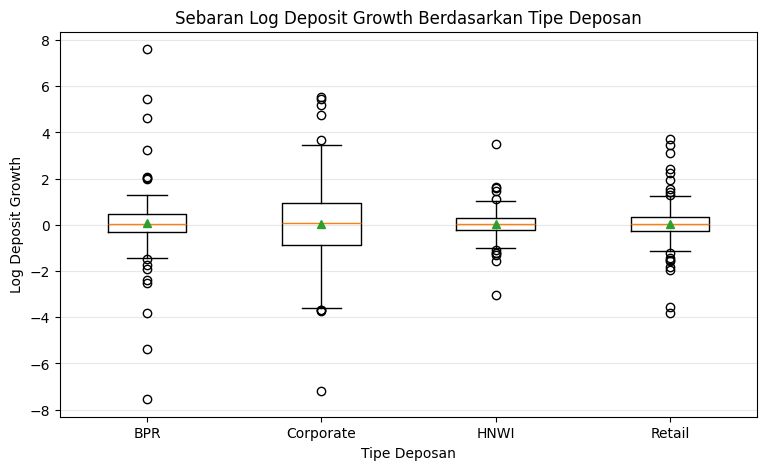

In [ ]:
# Menyiapkan data untuk boxplot log_deposit_growth
log_growth_plot_data = feature_data.dropna(subset=["log_deposit_growth"]).copy()

depositor_order = ["BPR", "Corporate", "HNWI", "Retail"]

boxplot_log_growth = [
    log_growth_plot_data[
        log_growth_plot_data["Type_Depositor"] == depositor
    ]["log_deposit_growth"]
    for depositor in depositor_order
]

plt.figure(figsize=(9, 5))
plt.boxplot(boxplot_log_growth, labels=depositor_order, showmeans=True)
plt.title("Sebaran Log Deposit Growth Berdasarkan Tipe Deposan")
plt.xlabel("Tipe Deposan")
plt.ylabel("Log Deposit Growth")
plt.grid(axis="y", alpha=0.3)
plt.show()

## Interpretasi Visualisasi Log Deposit Growth

Boxplot log deposit growth menunjukkan bahwa median pertumbuhan pada seluruh tipe deposan berada di sekitar nol. Artinya, sebagian besar perubahan deposit antar periode tidak selalu mengalami lonjakan besar, tetapi bergerak naik dan turun di sekitar nilai pertumbuhan yang relatif kecil.

Corporate memiliki sebaran yang paling lebar dibandingkan tipe deposan lain. Hal ini menunjukkan bahwa pertumbuhan deposit Corporate lebih fluktuatif. BPR juga memiliki banyak outlier, baik positif maupun negatif, yang menunjukkan adanya beberapa periode dengan perubahan deposit yang sangat tajam.

HNWI terlihat lebih stabil karena rentang boxplotnya lebih sempit. Retail juga relatif lebih stabil dibandingkan BPR dan Corporate, meskipun masih memiliki beberapa outlier.

Secara umum, visualisasi ini menunjukkan bahwa risiko perubahan deposit tidak sama pada setiap tipe deposan. BPR dan Corporate perlu mendapat perhatian lebih dari sisi volatilitas pertumbuhan, sedangkan HNWI tetap penting karena nilai depositnya besar meskipun pertumbuhan log-nya relatif lebih stabil.

## Feature Engineering 3: Lag Deposit dan Rolling Volatility

Pada tahap ini dibuat beberapa fitur tambahan untuk menangkap pola waktu pada data deposit. Fitur `lag_deposit_4` digunakan untuk melihat nilai deposit empat periode sebelumnya. Fitur `rolling_mean_4` digunakan untuk melihat rata-rata deposit dalam empat periode terakhir, sedangkan `rolling_std_4` digunakan untuk melihat volatilitas deposit dalam empat periode terakhir.

Fitur ini penting karena data deposit bersifat runtut waktu. Nilai deposit pada suatu periode dapat dipengaruhi oleh pola deposit pada periode-periode sebelumnya.

In [ ]:
# Mengurutkan data kembali berdasarkan tipe deposan dan periode
feature_data = feature_data.sort_values(
    by=["Type_Depositor", "Period"]
).reset_index(drop=True)

# Membuat lag deposit 4 periode sebelumnya
feature_data["lag_deposit_4"] = (
    feature_data
    .groupby("Type_Depositor")["Total_Deposit"]
    .shift(4)
)

# Membuat rolling mean 4 periode
feature_data["rolling_mean_4"] = (
    feature_data
    .groupby("Type_Depositor")["Total_Deposit"]
    .transform(lambda x: x.rolling(window=4, min_periods=2).mean())
)

# Membuat rolling standard deviation 4 periode
feature_data["rolling_std_4"] = (
    feature_data
    .groupby("Type_Depositor")["Total_Deposit"]
    .transform(lambda x: x.rolling(window=4, min_periods=2).std())
)

# Menampilkan hasil awal fitur baru
feature_data[
    [
        "Period",
        "Type_Depositor",
        "Total_Deposit",
        "lag_deposit_1",
        "lag_deposit_4",
        "rolling_mean_4",
        "rolling_std_4"
    ]
].head(12)

,Period,Type_Depositor,Total_Deposit,lag_deposit_1,lag_deposit_4,rolling_mean_4,rolling_std_4
0,2021-08-30,BPR,11000000,NaN,NaN,NaN,NaN
1,2021-09-06,BPR,1000000,1.100000e+07,NaN,6.000000e+06,7.071068e+06
2,2021-11-08,BPR,2000000000,1.000000e+06,NaN,6.706667e+08,1.151247e+09
3,2021-11-15,BPR,2100000000,2.000000e+09,NaN,1.028000e+09,1.180817e+09
4,2021-11-22,BPR,16000000000,2.100000e+09,1.100000e+07,5.025250e+09,7.380096e+09
5,2021-11-29,BPR,15900000000,1.600000e+10,1.000000e+06,9.000000e+09,8.025376e+09
6,2021-12-13,BPR,75000000,1.590000e+10,2.000000e+09,8.518750e+09,8.620696e+09
7,2021-12-20,BPR,17500000000,7.500000e+07,2.100000e+09,1.236875e+10,8.228441e+09
8,2021-12-27,BPR,19000000000,1.750000e+10,1.600000e+10,1.311875e+10,8.787476e+09
9,2022-01-03,BPR,10000000,1.900000e+10,1.590000e+10,9.146250e+09,1.052996e+10


In [ ]:
# Mengecek missing value pada fitur lag dan rolling
feature_data[
    [
        "lag_deposit_1",
        "lag_deposit_4",
        "rolling_mean_4",
        "rolling_std_4"
    ]
].isna().sum()

,0
lag_deposit_1,4
lag_deposit_4,16
rolling_mean_4,4
rolling_std_4,4


## Interpretasi Fitur Lag dan Rolling

Fitur lag dan rolling berhasil dibuat untuk menangkap pola waktu pada data deposit. Hasil pengecekan menunjukkan bahwa terdapat missing value pada beberapa fitur baru.

Missing value pada `lag_deposit_1` berjumlah 4 karena setiap tipe deposan memiliki satu observasi awal yang tidak memiliki periode sebelumnya. Missing value pada `lag_deposit_4` berjumlah 16 karena setiap tipe deposan membutuhkan empat periode sebelumnya untuk membentuk nilai lag empat periode.

Missing value pada `rolling_mean_4` dan `rolling_std_4` juga masih wajar karena baris awal setiap tipe deposan belum memiliki data historis yang cukup. Dengan demikian, missing value pada fitur ini bukan disebabkan oleh kesalahan data, tetapi muncul karena karakteristik perhitungan data runtut waktu.

## Visualisasi 6: Rolling Volatility Deposit Berdasarkan Tipe Deposan

Visualisasi ini digunakan untuk melihat volatilitas deposit dalam empat periode terakhir pada setiap tipe deposan. Fitur yang digunakan adalah `rolling_std_4`, yaitu standar deviasi deposit dalam jendela empat periode.

Semakin tinggi nilai `rolling_std_4`, semakin besar perubahan nilai deposit dalam beberapa periode terakhir. Dalam konteks stabilitas pendanaan, volatilitas yang tinggi perlu diperhatikan karena menunjukkan bahwa nilai simpanan dapat berubah cukup tajam dari waktu ke waktu.

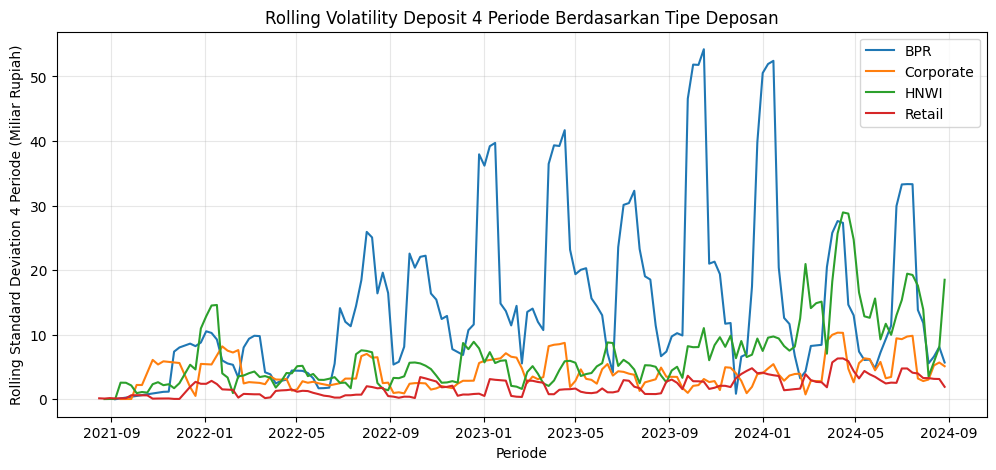

In [ ]:
# Membuat salinan data untuk visualisasi rolling volatility
rolling_plot_data = feature_data.dropna(subset=["rolling_std_4"]).copy()

# Mengubah rolling_std_4 ke satuan miliar rupiah agar lebih mudah dibaca
rolling_plot_data["rolling_std_4_billion"] = (
    rolling_plot_data["rolling_std_4"] / 1_000_000_000
)

plt.figure(figsize=(12, 5))

for depositor in ["BPR", "Corporate", "HNWI", "Retail"]:
    subset = rolling_plot_data[
        rolling_plot_data["Type_Depositor"] == depositor
    ]
    plt.plot(
        subset["Period"],
        subset["rolling_std_4_billion"],
        label=depositor
    )

plt.title("Rolling Volatility Deposit 4 Periode Berdasarkan Tipe Deposan")
plt.xlabel("Periode")
plt.ylabel("Rolling Standard Deviation 4 Periode (Miliar Rupiah)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Interpretasi Visualisasi Rolling Volatility Deposit

Grafik rolling volatility menunjukkan bahwa volatilitas deposit tidak sama pada setiap tipe deposan. BPR memiliki nilai rolling standard deviation paling tinggi dibandingkan Corporate, HNWI, dan Retail. Hal ini menunjukkan bahwa deposit dari kelompok BPR mengalami perubahan nilai yang lebih tajam dalam beberapa periode tertentu.

Lonjakan volatilitas BPR terlihat cukup kuat pada tahun 2023 hingga awal 2024. Kondisi ini menunjukkan bahwa meskipun BPR menjadi salah satu penyumbang deposit terbesar, pergerakan nilainya juga cukup fluktuatif. Dalam konteks stabilitas pendanaan, hal ini perlu diperhatikan karena perubahan deposit yang besar dapat memengaruhi kestabilan sumber dana.

HNWI juga menunjukkan peningkatan volatilitas pada beberapa periode, khususnya mendekati tahun 2024. Namun, volatilitas HNWI masih lebih rendah dibandingkan BPR. Sementara itu, Corporate dan Retail cenderung memiliki volatilitas yang lebih rendah, meskipun tetap terdapat beberapa kenaikan pada periode tertentu.

Secara umum, visualisasi ini menunjukkan bahwa risiko stabilitas pendanaan tidak hanya berasal dari besarnya nilai deposit, tetapi juga dari seberapa besar perubahan deposit dalam beberapa periode terakhir. BPR dan HNWI perlu mendapat perhatian khusus karena keduanya memiliki nilai deposit yang besar, sementara BPR juga menunjukkan volatilitas yang tinggi.

## Feature Engineering 4: Konsentrasi Deposit dengan HHI

Pada tahap ini dibuat ukuran konsentrasi deposit menggunakan Herfindahl-Hirschman Index atau HHI. HHI dihitung dari penjumlahan kuadrat proporsi deposit setiap tipe deposan dalam satu periode.

Nilai HHI yang lebih tinggi menunjukkan bahwa deposit lebih terkonsentrasi pada tipe deposan tertentu. Sebaliknya, nilai HHI yang lebih rendah menunjukkan bahwa deposit lebih tersebar antar tipe deposan.

Dalam konteks stabilitas pendanaan, konsentrasi deposit yang tinggi perlu diperhatikan karena ketergantungan pada kelompok deposan tertentu dapat meningkatkan risiko apabila kelompok tersebut mengalami perubahan perilaku simpanan.

In [ ]:
# Membuat data untuk menghitung konsentrasi deposit
hhi_data = type_clean.copy()

# Mengubah persentase menjadi proporsi
hhi_data["deposit_share"] = hhi_data["Percentage"] / 100

# Menghitung HHI per periode
hhi_by_period = (
    hhi_data
    .groupby("Period")
    .apply(lambda x: (x["deposit_share"] ** 2).sum())
    .reset_index(name="HHI")
)

hhi_by_period.head()

,Period,HHI
0,2021-08-09,1.000000
1,2021-08-16,0.561882
2,2021-08-23,0.502664
3,2021-08-30,0.480017
4,2021-09-06,0.508993


In [ ]:
# Statistik deskriptif HHI
hhi_by_period["HHI"].describe()

,HHI
count,159.000000
mean,0.447476
std,0.121634
min,0.298787
25%,0.364142
50%,0.416098
75%,0.498842
max,1.000000


## Interpretasi Awal HHI

Hasil perhitungan HHI menunjukkan bahwa tingkat konsentrasi deposit pada dataset cukup tinggi. Nilai rata-rata HHI sebesar 0,4475 menunjukkan bahwa simpanan deposito tidak tersebar merata pada seluruh tipe deposan.

Nilai minimum HHI sebesar 0,2988 menunjukkan periode dengan distribusi deposit yang relatif lebih tersebar. Sementara itu, nilai maksimum HHI sebesar 1,0000 menunjukkan periode ketika deposit hanya terkonsentrasi pada satu tipe deposan. Kondisi ini muncul pada periode awal data, ketika belum semua tipe deposan tercatat dalam dataset.

Dalam konteks stabilitas pendanaan, nilai HHI yang relatif tinggi perlu diperhatikan karena menunjukkan adanya ketergantungan terhadap kelompok deposan tertentu. Jika kelompok deposan dominan mengalami perubahan perilaku simpanan, maka stabilitas pendanaan BPR dapat ikut terpengaruh.

## Visualisasi 7: Tren Konsentrasi Deposit Berdasarkan HHI

Visualisasi ini digunakan untuk melihat perubahan tingkat konsentrasi deposit dari waktu ke waktu. Nilai HHI yang meningkat menunjukkan bahwa deposit semakin terkonsentrasi pada tipe deposan tertentu. Sebaliknya, nilai HHI yang menurun menunjukkan bahwa deposit lebih tersebar antar tipe deposan.

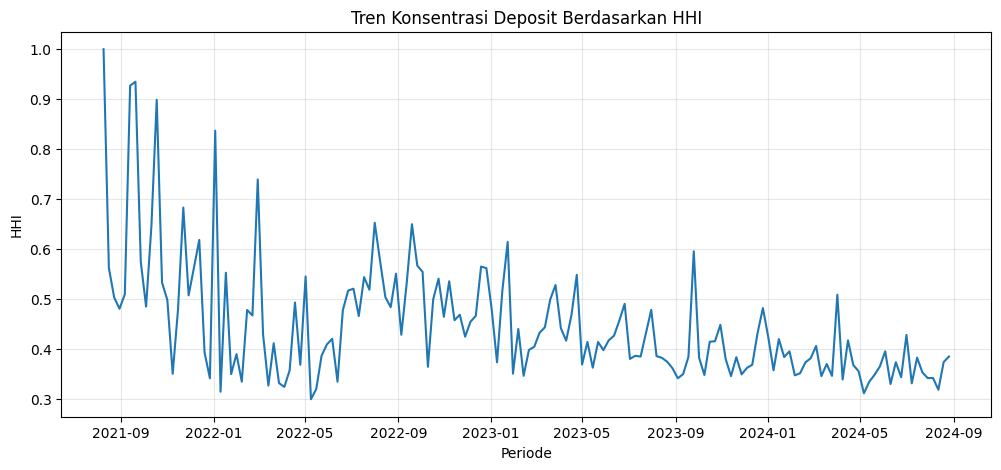

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    hhi_by_period["Period"],
    hhi_by_period["HHI"]
)

plt.title("Tren Konsentrasi Deposit Berdasarkan HHI")
plt.xlabel("Periode")
plt.ylabel("HHI")
plt.grid(alpha=0.3)
plt.show()

## Interpretasi Visualisasi HHI

Grafik HHI menunjukkan bahwa tingkat konsentrasi deposit mengalami perubahan dari waktu ke waktu. Pada periode awal, nilai HHI terlihat sangat tinggi, bahkan mendekati 1. Kondisi ini menunjukkan bahwa deposit pada periode tersebut sangat terkonsentrasi pada satu tipe deposan.

Setelah periode awal, nilai HHI cenderung menurun dan bergerak lebih stabil. Pada sebagian besar periode 2022 sampai 2024, nilai HHI berada di sekitar 0,3 sampai 0,5. Hal ini menunjukkan bahwa distribusi deposit mulai lebih tersebar antar tipe deposan, meskipun konsentrasi tetap terlihat.

Dalam konteks stabilitas pendanaan, tren HHI ini penting karena menunjukkan bahwa risiko tidak hanya berasal dari besar kecilnya total deposit, tetapi juga dari struktur penyumbang deposit. Jika deposit terlalu bergantung pada satu tipe deposan, maka perubahan perilaku deposan tersebut dapat memengaruhi kestabilan pendanaan.

Namun, hasil ini belum dapat langsung disimpulkan sebagai bukti terjadinya flight to quality. HHI hanya menunjukkan tingkat konsentrasi deposit. Untuk membaca indikasi risiko secara lebih lengkap, perlu dilihat juga tipe deposan mana yang paling dominan pada periode dengan HHI tinggi.

## Analisis Deposan Dominan pada Periode Konsentrasi Tinggi

Setelah HHI dihitung, langkah berikutnya adalah melihat tipe deposan yang paling dominan pada setiap periode. Analisis ini diperlukan untuk mengetahui apakah konsentrasi deposit lebih sering didorong oleh BPR, HNWI, Corporate, atau Retail.

Dengan cara ini, HHI tidak hanya dibaca sebagai angka konsentrasi, tetapi juga dikaitkan dengan struktur deposan yang membentuk konsentrasi tersebut.

In [ ]:
# Mengambil tipe deposan dengan kontribusi terbesar pada setiap periode
dominant_depositor = (
    hhi_data
    .loc[hhi_data.groupby("Period")["deposit_share"].idxmax()]
    [["Period", "Type_Depositor", "deposit_share"]]
    .rename(columns={
        "Type_Depositor": "Dominant_Depositor",
        "deposit_share": "Dominant_Share"
    })
)

# Menggabungkan HHI dengan deposan dominan
hhi_detail = hhi_by_period.merge(
    dominant_depositor,
    on="Period",
    how="left"
)

# Mengubah share dominan ke persen
hhi_detail["Dominant_Share_Percent"] = hhi_detail["Dominant_Share"] * 100

# Menampilkan 10 periode dengan HHI tertinggi
hhi_detail.sort_values("HHI", ascending=False).head(10)

,Period,HHI,Dominant_Depositor,Dominant_Share,Dominant_Share_Percent
0,2021-08-09,1.000000,Retail,1.0000,100.00
6,2021-09-20,0.934871,HNWI,0.9663,96.63
5,2021-09-13,0.927109,HNWI,0.9625,96.25
10,2021-10-18,0.898546,HNWI,0.9464,94.64
20,2022-01-03,0.836846,HNWI,0.9110,91.10
28,2022-02-28,0.739198,HNWI,0.8555,85.55
15,2021-11-22,0.682724,BPR,0.8042,80.42
50,2022-08-01,0.652321,BPR,0.7957,79.57
57,2022-09-19,0.649418,BPR,0.7841,78.41
9,2021-10-11,0.645607,HNWI,0.7880,78.80


In [ ]:
# Menghitung berapa kali setiap tipe deposan menjadi deposan dominan
hhi_detail["Dominant_Depositor"].value_counts()

,count
Dominant_Depositor,
BPR,82
HNWI,68
Retail,5
Corporate,4


## Interpretasi Deposan Dominan pada Periode Konsentrasi Tinggi

Hasil analisis menunjukkan bahwa tipe deposan yang paling sering menjadi penyumbang deposit terbesar adalah BPR dan HNWI. BPR menjadi deposan dominan pada 82 periode, sedangkan HNWI menjadi deposan dominan pada 68 periode. Retail dan Corporate hanya beberapa kali menjadi deposan dominan.

Pada 10 periode dengan HHI tertinggi, konsentrasi deposit banyak didorong oleh HNWI. Beberapa periode menunjukkan kontribusi HNWI di atas 90 persen dari total deposit. Hal ini menunjukkan bahwa pada periode tertentu, struktur deposit sangat bergantung pada kelompok deposan besar.

Temuan ini penting dalam konteks stabilitas pendanaan. Ketika deposit terlalu terkonsentrasi pada kelompok deposan tertentu, risiko pendanaan dapat meningkat apabila kelompok tersebut mengubah perilaku simpanannya. Namun, hasil ini tetap dibaca sebagai indikasi risiko konsentrasi, bukan sebagai bukti langsung terjadinya flight to quality.

Secara umum, hasil HHI dan deposan dominan menunjukkan bahwa BPR dan HNWI merupakan kelompok yang paling berpengaruh terhadap struktur deposit dalam dataset. Oleh karena itu, kedua kelompok ini perlu menjadi perhatian utama dalam analisis risiko stabilitas pendanaan BPR.

## Visualisasi 8: Jumlah Periode Deposan Dominan

Visualisasi ini digunakan untuk melihat tipe deposan mana yang paling sering menjadi penyumbang deposit terbesar pada setiap periode. Grafik ini membantu menjelaskan struktur dominasi deposan secara lebih mudah dibandingkan hanya membaca tabel.

In [ ]:
# Menghitung jumlah periode setiap tipe deposan menjadi dominan
dominant_count = (
    hhi_detail["Dominant_Depositor"]
    .value_counts()
    .reset_index()
)

dominant_count.columns = ["Dominant_Depositor", "Count"]

dominant_count

,Dominant_Depositor,Count
0,BPR,82
1,HNWI,68
2,Retail,5
3,Corporate,4


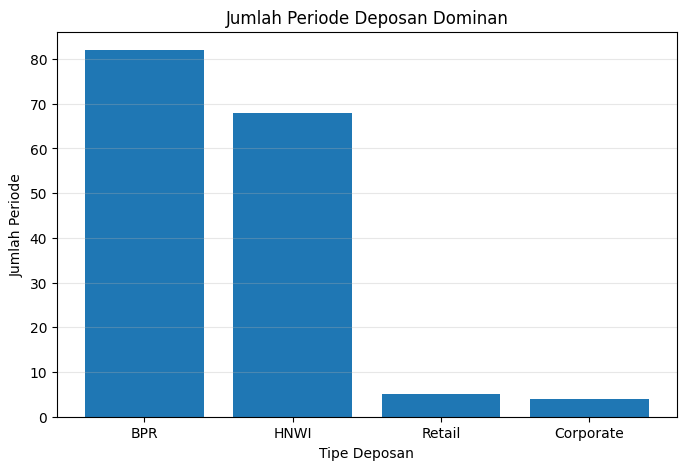

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    dominant_count["Dominant_Depositor"],
    dominant_count["Count"]
)

plt.title("Jumlah Periode Deposan Dominan")
plt.xlabel("Tipe Deposan")
plt.ylabel("Jumlah Periode")
plt.grid(axis="y", alpha=0.3)
plt.show()

## Interpretasi Visualisasi Jumlah Periode Deposan Dominan

Grafik jumlah periode deposan dominan menunjukkan bahwa BPR dan HNWI merupakan tipe deposan yang paling sering menjadi penyumbang deposit terbesar. BPR menjadi deposan dominan pada 82 periode, sedangkan HNWI menjadi deposan dominan pada 68 periode.

Retail dan Corporate jauh lebih jarang menjadi deposan dominan. Retail hanya menjadi deposan dominan pada 5 periode, sedangkan Corporate hanya pada 4 periode. Hal ini menunjukkan bahwa struktur deposit dalam dataset lebih banyak dipengaruhi oleh BPR dan HNWI.

Dalam konteks stabilitas pendanaan, temuan ini penting karena menunjukkan adanya ketergantungan pada kelompok deposan tertentu. Jika BPR atau HNWI mengalami perubahan perilaku simpanan, maka struktur pendanaan BPR dapat ikut terdampak.

Temuan ini belum membuktikan terjadinya flight to quality secara langsung. Namun, dominasi BPR dan HNWI dapat dibaca sebagai indikasi risiko konsentrasi dana, terutama karena kedua kelompok tersebut memiliki kontribusi besar terhadap total deposit.

## Uji Statistik: Perbedaan Total Deposit Antar Tipe Deposan

Setelah pola visual dianalisis, langkah berikutnya adalah melakukan uji statistik untuk melihat apakah terdapat perbedaan nilai total deposit antar tipe deposan.

Uji yang digunakan adalah Kruskal-Wallis. Uji ini dipilih karena data deposit memiliki sebaran yang tidak merata, terdapat outlier, dan dibandingkan pada lebih dari dua kelompok deposan.

Hipotesis yang digunakan adalah:

H0: Tidak terdapat perbedaan distribusi total deposit antar tipe deposan.

H1: Terdapat perbedaan distribusi total deposit antar tipe deposan.

In [ ]:
# Menyiapkan data untuk uji statistik
stat_test_data = type_clean.copy()
stat_test_data["Total_Deposit_Billion"] = (
    stat_test_data["Total_Deposit"] / 1_000_000_000
)

# Membuat kelompok data berdasarkan tipe deposan
depositor_order = ["BPR", "Corporate", "HNWI", "Retail"]

groups = [
    stat_test_data[
        stat_test_data["Type_Depositor"] == depositor
    ]["Total_Deposit_Billion"].dropna()
    for depositor in depositor_order
]

# Melakukan uji Kruskal-Wallis
kruskal_stat, kruskal_pvalue = kruskal(*groups)

# Menampilkan hasil uji
kruskal_result = pd.DataFrame({
    "Test": ["Kruskal-Wallis"],
    "Statistic": [kruskal_stat],
    "P_Value": [kruskal_pvalue]
})

kruskal_result

,Test,Statistic,P_Value
0,Kruskal-Wallis,243.090771,2.042254e-52


## Interpretasi Uji Kruskal-Wallis

Hasil uji Kruskal-Wallis menunjukkan nilai p-value sebesar 2,042254e-52. Nilai ini jauh lebih kecil dari tingkat signifikansi 0,05. Dengan demikian, H0 ditolak.

Artinya, terdapat perbedaan distribusi total deposit yang signifikan antar tipe deposan. Hasil ini mendukung temuan visual sebelumnya bahwa nilai deposit BPR, HNWI, Corporate, dan Retail tidak memiliki pola distribusi yang sama.

Namun, uji Kruskal-Wallis hanya menunjukkan bahwa terdapat perbedaan secara umum antar kelompok. Uji ini belum menunjukkan pasangan tipe deposan mana yang berbeda secara signifikan. Oleh karena itu, analisis dilanjutkan dengan uji post-hoc menggunakan Mann-Whitney U Test dengan koreksi Bonferroni.

## Uji Post-Hoc: Mann-Whitney U Test dengan Koreksi Bonferroni

Karena uji Kruskal-Wallis menunjukkan adanya perbedaan signifikan antar tipe deposan, maka dilakukan uji lanjutan untuk membandingkan setiap pasangan tipe deposan.

Uji yang digunakan adalah Mann-Whitney U Test. Koreksi Bonferroni digunakan untuk mengurangi risiko kesalahan akibat pengujian berulang pada beberapa pasangan kelompok.

In [ ]:
from scipy.stats import mannwhitneyu
from itertools import combinations

# Menyiapkan hasil uji post-hoc
pairwise_results = []

for dep1, dep2 in combinations(depositor_order, 2):
    data1 = stat_test_data[
        stat_test_data["Type_Depositor"] == dep1
    ]["Total_Deposit_Billion"].dropna()

    data2 = stat_test_data[
        stat_test_data["Type_Depositor"] == dep2
    ]["Total_Deposit_Billion"].dropna()

    stat, p_value = mannwhitneyu(
        data1,
        data2,
        alternative="two-sided"
    )

    pairwise_results.append({
        "Group_1": dep1,
        "Group_2": dep2,
        "Statistic": stat,
        "P_Value": p_value
    })

pairwise_result = pd.DataFrame(pairwise_results)

# Koreksi Bonferroni
pairwise_result["P_Value_Bonferroni"] = (
    pairwise_result["P_Value"] * len(pairwise_result)
).clip(upper=1)

# Menentukan signifikansi setelah koreksi
pairwise_result["Significant_0_05"] = (
    pairwise_result["P_Value_Bonferroni"] < 0.05
)

pairwise_result

,Group_1,Group_2,Statistic,P_Value,P_Value_Bonferroni,Significant_0_05
0,BPR,Corporate,19036.0,5.187610e-32,3.112566e-31,True
1,BPR,HNWI,13746.0,5.588922e-03,3.353353e-02,True
2,BPR,Retail,20779.5,6.393970e-32,3.836382e-31,True
3,Corporate,HNWI,3656.5,2.334847e-24,1.400908e-23,True
4,Corporate,Retail,11687.5,7.536611e-01,1.000000e+00,False
5,HNWI,Retail,20679.0,2.551510e-23,1.530906e-22,True


## Interpretasi Uji Post-Hoc Mann-Whitney

Hasil uji post-hoc Mann-Whitney dengan koreksi Bonferroni menunjukkan bahwa sebagian besar pasangan tipe deposan memiliki perbedaan distribusi total deposit yang signifikan.

Pasangan BPR dengan Corporate, BPR dengan HNWI, dan BPR dengan Retail memiliki nilai p-value Bonferroni di bawah 0,05. Hal ini menunjukkan bahwa distribusi total deposit BPR berbeda signifikan dibandingkan tipe deposan lainnya.

HNWI juga berbeda signifikan dibandingkan Corporate dan Retail. Temuan ini memperkuat hasil visualisasi sebelumnya bahwa BPR dan HNWI memiliki karakteristik deposit yang berbeda dari kelompok deposan lain.

Satu-satunya pasangan yang tidak berbeda signifikan adalah Corporate dan Retail. Hal ini menunjukkan bahwa distribusi total deposit Corporate dan Retail relatif lebih mirip dibandingkan pasangan deposan lainnya.

Secara umum, hasil uji statistik menunjukkan bahwa struktur deposit antar tipe deposan tidak homogen. Dalam konteks stabilitas pendanaan, perbedaan ini penting karena menunjukkan bahwa setiap tipe deposan memiliki karakteristik dan potensi risiko yang berbeda.

## Ringkasan Statistik Total Deposit per Tipe Deposan

Setelah uji statistik dilakukan, dibuat tabel ringkasan untuk melihat arah perbedaan nilai deposit antar tipe deposan. Tabel ini menampilkan jumlah observasi, rata-rata, median, standar deviasi, nilai minimum, dan nilai maksimum total deposit dalam satuan miliar rupiah.

In [ ]:
# Ringkasan statistik total deposit per tipe deposan
deposit_group_summary = (
    stat_test_data
    .groupby("Type_Depositor")["Total_Deposit_Billion"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Std="std",
        Min="min",
        Max="max"
    )
    .reset_index()
    .sort_values("Median", ascending=False)
)

deposit_group_summary

,Type_Depositor,Count,Mean,Median,Std,Min,Max
0,BPR,147,38.863756,37.75000,25.766375,0.0010,139.6500
2,HNWI,158,32.172760,23.70095,27.876215,0.1055,115.8252
1,Corporate,144,6.572195,5.53000,5.707475,0.0100,28.8375
3,Retail,159,7.263697,3.84250,7.371114,0.0100,28.1854


## Interpretasi Ringkasan Statistik Total Deposit per Tipe Deposan

Ringkasan statistik menunjukkan bahwa BPR memiliki nilai total deposit paling besar dibandingkan tipe deposan lain. Rata-rata deposit BPR sebesar 38,86 miliar rupiah dengan median 37,75 miliar rupiah. Hal ini menunjukkan bahwa BPR merupakan salah satu kelompok deposan utama dalam dataset.

HNWI berada pada posisi kedua dengan rata-rata 32,17 miliar rupiah dan median 23,70 miliar rupiah. Meskipun median HNWI lebih rendah dibanding BPR, nilai maksimum HNWI mencapai 115,83 miliar rupiah. Hal ini menunjukkan bahwa HNWI tetap menjadi kelompok deposan besar yang perlu diperhatikan dalam analisis stabilitas pendanaan.

Corporate dan Retail memiliki nilai deposit yang lebih rendah dibandingkan BPR dan HNWI. Corporate memiliki median 5,53 miliar rupiah, sedangkan Retail memiliki median 3,84 miliar rupiah. Nilai ini sejalan dengan hasil uji post-hoc sebelumnya yang menunjukkan bahwa Corporate dan Retail tidak berbeda signifikan.

Secara umum, hasil ini memperkuat temuan bahwa struktur deposit dalam dataset tidak tersebar merata. BPR dan HNWI menjadi kelompok deposan yang paling besar kontribusinya, sedangkan Corporate dan Retail cenderung lebih kecil. Dalam konteks risiko stabilitas pendanaan, ketergantungan pada BPR dan HNWI perlu diperhatikan karena perubahan perilaku pada kedua kelompok tersebut dapat berdampak pada struktur deposit secara keseluruhan.

## Kesimpulan Sementara dari Uji Statistik

Hasil uji statistik menunjukkan bahwa terdapat perbedaan signifikan nilai total deposit antar tipe deposan. Perbedaan paling kuat terlihat antara kelompok deposan besar, yaitu BPR dan HNWI, dibandingkan kelompok deposan yang lebih kecil, yaitu Corporate dan Retail.

Temuan ini mendukung hasil EDA sebelumnya bahwa risiko stabilitas pendanaan tidak dapat dilihat hanya dari total deposit secara keseluruhan. Analisis perlu memperhatikan tipe deposan karena setiap kelompok memiliki karakteristik nilai, volatilitas, dan dominasi yang berbeda.

Sampai tahap ini, hasil analisis menunjukkan adanya indikasi risiko konsentrasi dana pada BPR dan HNWI. Namun, hasil ini tetap tidak digunakan untuk menyimpulkan terjadinya flight to quality secara kausal.

## Modelling Prediksi Total Deposit

Pada tahap ini dilakukan modelling untuk memprediksi nilai total deposit berdasarkan pola historis data. Tujuan modelling bukan untuk membuktikan terjadinya flight to quality, tetapi untuk melihat apakah pola waktu dan karakteristik tipe deposan dapat digunakan untuk memperkirakan nilai deposit.

Agar modelling tidak mengalami data leakage, fitur yang digunakan harus berasal dari informasi periode sebelumnya. Oleh karena itu, fitur seperti `log_deposit_growth` tidak digunakan sebagai prediktor karena fitur tersebut dihitung menggunakan nilai deposit pada periode yang sama dengan target.

Fitur yang digunakan dalam modelling adalah tipe deposan, tahun, bulan, nilai deposit periode sebelumnya, nilai deposit empat periode sebelumnya, rata-rata deposit historis empat periode sebelumnya, dan volatilitas historis empat periode sebelumnya.

In [ ]:
# Menyiapkan data untuk modelling
model_data = feature_data.copy()

# Mengurutkan data berdasarkan tipe deposan dan periode
model_data = model_data.sort_values(
    by=["Type_Depositor", "Period"]
).reset_index(drop=True)

# Target prediksi dalam satuan miliar rupiah
model_data["Target_Deposit_Billion"] = (
    model_data["Total_Deposit"] / 1_000_000_000
)

# Membuat fitur waktu
model_data["Year"] = model_data["Period"].dt.year
model_data["Month_Number"] = model_data["Period"].dt.month

# Membuat fitur historis yang aman dari data leakage
model_data["lag_deposit_1_billion"] = (
    model_data
    .groupby("Type_Depositor")["Total_Deposit"]
    .shift(1) / 1_000_000_000
)

model_data["lag_deposit_4_billion"] = (
    model_data
    .groupby("Type_Depositor")["Total_Deposit"]
    .shift(4) / 1_000_000_000
)

# Rolling mean dan rolling std dibuat dari data periode sebelumnya
model_data["rolling_mean_4_prev_billion"] = (
    model_data
    .groupby("Type_Depositor")["Total_Deposit"]
    .transform(lambda x: x.shift(1).rolling(window=4, min_periods=2).mean())
    / 1_000_000_000
)

model_data["rolling_std_4_prev_billion"] = (
    model_data
    .groupby("Type_Depositor")["Total_Deposit"]
    .transform(lambda x: x.shift(1).rolling(window=4, min_periods=2).std())
    / 1_000_000_000
)

# Menampilkan data awal untuk modelling
model_data[
    [
        "Period",
        "Type_Depositor",
        "Target_Deposit_Billion",
        "Year",
        "Month_Number",
        "lag_deposit_1_billion",
        "lag_deposit_4_billion",
        "rolling_mean_4_prev_billion",
        "rolling_std_4_prev_billion"
    ]
].head(12)

,Period,Type_Depositor,Target_Deposit_Billion,Year,Month_Number,lag_deposit_1_billion,lag_deposit_4_billion,rolling_mean_4_prev_billion,rolling_std_4_prev_billion
0,2021-08-30,BPR,0.011,2021,8,NaN,NaN,NaN,NaN
1,2021-09-06,BPR,0.001,2021,9,0.011,NaN,NaN,NaN
2,2021-11-08,BPR,2.000,2021,11,0.001,NaN,0.006000,0.007071
3,2021-11-15,BPR,2.100,2021,11,2.000,NaN,0.670667,1.151247
4,2021-11-22,BPR,16.000,2021,11,2.100,0.011,1.028000,1.180817
5,2021-11-29,BPR,15.900,2021,11,16.000,0.001,5.025250,7.380096
6,2021-12-13,BPR,0.075,2021,12,15.900,2.000,9.000000,8.025376
7,2021-12-20,BPR,17.500,2021,12,0.075,2.100,8.518750,8.620696
8,2021-12-27,BPR,19.000,2021,12,17.500,16.000,12.368750,8.228441
9,2022-01-03,BPR,0.010,2022,1,19.000,15.900,13.118750,8.787476


In [ ]:
# Mengecek missing value pada fitur modelling
model_features_check = model_data[
    [
        "Type_Depositor",
        "Year",
        "Month_Number",
        "lag_deposit_1_billion",
        "lag_deposit_4_billion",
        "rolling_mean_4_prev_billion",
        "rolling_std_4_prev_billion",
        "Target_Deposit_Billion"
    ]
]

model_features_check.isna().sum()

,0
Type_Depositor,0
Year,0
Month_Number,0
lag_deposit_1_billion,4
lag_deposit_4_billion,16
rolling_mean_4_prev_billion,8
rolling_std_4_prev_billion,8
Target_Deposit_Billion,0


## Interpretasi Missing Value pada Data Modelling

Hasil pengecekan menunjukkan bahwa beberapa fitur historis memiliki missing value. Missing value ini muncul karena fitur lag dan rolling membutuhkan data dari periode sebelumnya.

Fitur `lag_deposit_1_billion` memiliki 4 missing value karena setiap tipe deposan memiliki satu observasi awal yang belum memiliki nilai deposit periode sebelumnya. Fitur `lag_deposit_4_billion` memiliki 16 missing value karena setiap tipe deposan membutuhkan empat periode sebelumnya.

Fitur `rolling_mean_4_prev_billion` dan `rolling_std_4_prev_billion` memiliki 8 missing value karena perhitungan rolling menggunakan data historis sebelumnya dan membutuhkan minimal dua observasi. Dengan demikian, missing value ini bukan berasal dari kerusakan data, tetapi dari karakteristik perhitungan time series.

Untuk modelling, baris yang masih memiliki missing value pada fitur prediktor akan dihapus agar model hanya dilatih menggunakan data yang lengkap.

In [ ]:
# Menentukan fitur yang digunakan untuk modelling
model_features = [
    "Type_Depositor",
    "Year",
    "Month_Number",
    "lag_deposit_1_billion",
    "lag_deposit_4_billion",
    "rolling_mean_4_prev_billion",
    "rolling_std_4_prev_billion"
]

target_column = "Target_Deposit_Billion"

# Menghapus baris yang memiliki missing value pada fitur modelling
model_ready = model_data.dropna(
    subset=model_features + [target_column]
).copy()

# Melihat jumlah data sebelum dan sesudah pembersihan
print("Jumlah data awal:", len(model_data))
print("Jumlah data siap modelling:", len(model_ready))
print("Jumlah data yang dihapus:", len(model_data) - len(model_ready))

model_ready[
    ["Period"] + model_features + [target_column]
].head()

Jumlah data awal: 608
Jumlah data siap modelling: 592
Jumlah data yang dihapus: 16


,Period,Type_Depositor,Year,Month_Number,lag_deposit_1_billion,lag_deposit_4_billion,rolling_mean_4_prev_billion,rolling_std_4_prev_billion,Target_Deposit_Billion
4,2021-11-22,BPR,2021,11,2.100,0.011,1.02800,1.180817,16.000
5,2021-11-29,BPR,2021,11,16.000,0.001,5.02525,7.380096,15.900
6,2021-12-13,BPR,2021,12,15.900,2.000,9.00000,8.025376,0.075
7,2021-12-20,BPR,2021,12,0.075,2.100,8.51875,8.620696,17.500
8,2021-12-27,BPR,2021,12,17.500,16.000,12.36875,8.228441,19.000


In [ ]:
# Membagi data train dan test berdasarkan waktu
# Data sebelum 2024 digunakan sebagai data training
# Data tahun 2024 digunakan sebagai data testing

cutoff_date = pd.Timestamp("2024-01-01")

train_data = model_ready[model_ready["Period"] < cutoff_date].copy()
test_data = model_ready[model_ready["Period"] >= cutoff_date].copy()

print("Jumlah data training:", len(train_data))
print("Jumlah data testing:", len(test_data))

print("Periode training:")
print(train_data["Period"].min(), "sampai", train_data["Period"].max())

print("Periode testing:")
print(test_data["Period"].min(), "sampai", test_data["Period"].max())

Jumlah data training: 452
Jumlah data testing: 140
Periode training:
2021-09-06 00:00:00 sampai 2023-12-25 00:00:00
Periode testing:
2024-01-01 00:00:00 sampai 2024-08-26 00:00:00


## Interpretasi Pembagian Data Training dan Testing

Data yang siap digunakan untuk modelling berjumlah 592 observasi dari total 608 observasi awal. Sebanyak 16 observasi dihapus karena memiliki missing value pada fitur historis, terutama `lag_deposit_4_billion` yang membutuhkan empat periode sebelumnya.

Data kemudian dibagi berdasarkan waktu. Data sebelum tahun 2024 digunakan sebagai data training, sedangkan data tahun 2024 digunakan sebagai data testing. Pembagian ini dipilih karena dataset bersifat runtut waktu, sehingga model sebaiknya dilatih menggunakan data masa lalu dan diuji pada data periode setelahnya.

Dengan pembagian ini, model tidak mengacak data secara random. Hal ini penting untuk menghindari kebocoran informasi dari masa depan ke masa lalu.

## Training Model Prediksi Total Deposit

Pada tahap ini dilakukan pelatihan beberapa model prediksi, yaitu Linear Regression, Random Forest Regressor, dan Gradient Boosting Regressor.

Linear Regression digunakan sebagai model dasar yang sederhana. Random Forest dan Gradient Boosting digunakan untuk menangkap pola non-linear pada data. Karena terdapat fitur kategorikal berupa `Type_Depositor`, fitur tersebut diubah menggunakan One-Hot Encoding agar dapat diproses oleh model machine learning.

In [ ]:
# Menentukan X dan y untuk training dan testing
X_train = train_data[model_features]
y_train = train_data[target_column]

X_test = test_data[model_features]
y_test = test_data[target_column]

# Memisahkan fitur kategorikal dan numerik
categorical_features = ["Type_Depositor"]

numeric_features = [
    "Year",
    "Month_Number",
    "lag_deposit_1_billion",
    "lag_deposit_4_billion",
    "rolling_mean_4_prev_billion",
    "rolling_std_4_prev_billion"
]

# Preprocessing: One-Hot Encoding untuk fitur kategorikal
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numeric", "passthrough", numeric_features)
    ]
)

# Menentukan model yang akan dibandingkan
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

In [ ]:
# Melatih dan mengevaluasi model
model_results = []
trained_models = {}

for model_name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    # Training model
    pipeline.fit(X_train, y_train)

    # Prediksi data testing
    y_pred = pipeline.predict(X_test)

    # Evaluasi model
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    model_results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2
    })

    trained_models[model_name] = pipeline

# Menampilkan hasil evaluasi model
model_results_df = pd.DataFrame(model_results).sort_values(
    by="RMSE",
    ascending=True
)

model_results_df

,Model,MAE,RMSE,MAPE,R2
0,Linear Regression,8.574200,12.854564,0.392974,0.791869
1,Random Forest,9.205825,13.074715,0.379938,0.784678
2,Gradient Boosting,9.732095,14.777344,0.355731,0.724947


## Interpretasi Hasil Evaluasi Model

Hasil evaluasi menunjukkan bahwa Linear Regression memiliki performa terbaik berdasarkan nilai RMSE terendah, yaitu 12,85 miliar rupiah. Model ini juga memiliki nilai MAE sebesar 8,57 miliar rupiah dan R2 sebesar 0,7919.

Nilai R2 sebesar 0,7919 menunjukkan bahwa model mampu menjelaskan sekitar 79,19 persen variasi total deposit pada data testing. Dengan demikian, pola historis deposit, tipe deposan, fitur waktu, lag deposit, rolling mean, dan rolling volatility cukup mampu membantu memprediksi total deposit.

Random Forest memiliki performa yang cukup dekat dengan Linear Regression, tetapi nilai RMSE dan MAE-nya sedikit lebih tinggi. Gradient Boosting memiliki nilai MAPE paling rendah, tetapi RMSE dan R2-nya lebih lemah dibandingkan dua model lainnya.

Dalam analisis ini, model terbaik dipilih berdasarkan RMSE karena target prediksi berupa nilai deposit dalam miliar rupiah. RMSE lebih sesuai untuk melihat besar kesalahan prediksi secara nominal, terutama ketika nilai deposit memiliki variasi yang besar.

## Visualisasi dan Pemeriksaan Prediksi Model Terbaik

Setelah model terbaik dipilih, langkah berikutnya adalah membandingkan nilai aktual dan nilai prediksi pada data testing. Perbandingan ini digunakan untuk melihat apakah model mengikuti pola nilai deposit sebenarnya atau justru menghasilkan prediksi yang terlalu jauh.

In [ ]:
# Memilih model terbaik berdasarkan RMSE
best_model_name = model_results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Model terbaik:", best_model_name)

# Membuat prediksi menggunakan model terbaik
test_prediction = test_data.copy()
test_prediction["Predicted_Deposit_Billion"] = best_model.predict(X_test)

# Menghitung error prediksi
test_prediction["Prediction_Error"] = (
    test_prediction["Target_Deposit_Billion"] -
    test_prediction["Predicted_Deposit_Billion"]
)

# Menampilkan hasil prediksi awal
test_prediction[
    [
        "Period",
        "Type_Depositor",
        "Target_Deposit_Billion",
        "Predicted_Deposit_Billion",
        "Prediction_Error"
    ]
].head(10)

Model terbaik: Linear Regression


,Period,Type_Depositor,Target_Deposit_Billion,Predicted_Deposit_Billion,Prediction_Error
112,2024-01-01,BPR,10.5000,59.633800,-49.133800
113,2024-01-08,BPR,37.5000,30.322170,7.177830
114,2024-01-15,BPR,31.8500,48.662479,-16.812479
115,2024-01-22,BPR,60.1500,62.749257,-2.599257
116,2024-01-29,BPR,49.2500,30.258533,18.991467
117,2024-02-05,BPR,46.5000,46.851988,-0.351988
118,2024-02-12,BPR,45.4750,45.186138,0.288862
119,2024-02-19,BPR,52.7500,60.250342,-7.500342
120,2024-02-26,BPR,54.0125,58.329965,-4.317465
121,2024-03-04,BPR,36.0500,57.770543,-21.720543


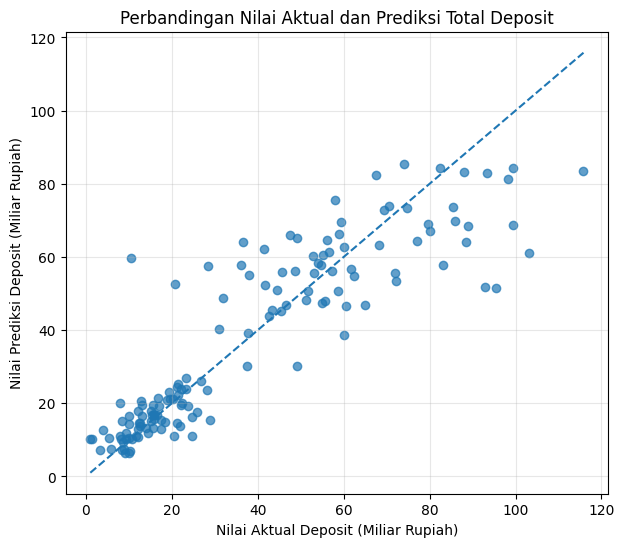

In [ ]:
plt.figure(figsize=(7, 6))

plt.scatter(
    test_prediction["Target_Deposit_Billion"],
    test_prediction["Predicted_Deposit_Billion"],
    alpha=0.7
)

# Garis ideal prediksi
min_value = min(
    test_prediction["Target_Deposit_Billion"].min(),
    test_prediction["Predicted_Deposit_Billion"].min()
)

max_value = max(
    test_prediction["Target_Deposit_Billion"].max(),
    test_prediction["Predicted_Deposit_Billion"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Perbandingan Nilai Aktual dan Prediksi Total Deposit")
plt.xlabel("Nilai Aktual Deposit (Miliar Rupiah)")
plt.ylabel("Nilai Prediksi Deposit (Miliar Rupiah)")
plt.grid(alpha=0.3)
plt.show()

## Interpretasi Visualisasi Aktual vs Prediksi

Grafik perbandingan nilai aktual dan prediksi menunjukkan bahwa model Linear Regression cukup mampu mengikuti pola total deposit pada data testing. Sebagian besar titik berada di sekitar garis diagonal, yang menunjukkan bahwa nilai prediksi tidak terlalu jauh dari nilai aktual.

Namun, pada beberapa nilai deposit yang besar, model cenderung menghasilkan prediksi yang lebih rendah dari nilai aktual. Hal ini menunjukkan bahwa model masih memiliki keterbatasan dalam menangkap lonjakan deposit yang tinggi. Kondisi ini wajar karena data deposit memiliki fluktuasi dan beberapa nilai ekstrem.

Secara umum, hasil visualisasi ini mendukung nilai evaluasi model sebelumnya. Nilai R2 sebesar 0,7919 menunjukkan bahwa model mampu menjelaskan sebagian besar variasi total deposit, tetapi belum sepenuhnya mampu menangkap perubahan ekstrem pada periode tertentu.

Dalam konteks analisis stabilitas pendanaan, hasil ini menunjukkan bahwa pola historis deposit dapat membantu memperkirakan nilai deposit, tetapi perubahan yang sangat tajam tetap perlu dipantau secara khusus.

## Analisis Error Prediksi Berdasarkan Tipe Deposan

Setelah membandingkan nilai aktual dan prediksi secara umum, langkah berikutnya adalah melihat besar error prediksi pada setiap tipe deposan. Analisis ini digunakan untuk mengetahui tipe deposan mana yang lebih sulit diprediksi oleh model.

Jika error pada suatu tipe deposan lebih besar, maka tipe deposan tersebut memiliki pola deposit yang lebih sulit ditangkap oleh model.

In [ ]:
# Menghitung absolute error
test_prediction["Absolute_Error"] = abs(test_prediction["Prediction_Error"])

# Ringkasan error prediksi berdasarkan tipe deposan
error_by_depositor = (
    test_prediction
    .groupby("Type_Depositor")
    .agg(
        Count=("Absolute_Error", "count"),
        MAE=("Absolute_Error", "mean"),
        RMSE=("Prediction_Error", lambda x: np.sqrt(np.mean(x ** 2))),
        Mean_Actual=("Target_Deposit_Billion", "mean"),
        Mean_Predicted=("Predicted_Deposit_Billion", "mean")
    )
    .reset_index()
    .sort_values("MAE", ascending=False)
)

error_by_depositor

,Type_Depositor,Count,MAE,RMSE,Mean_Actual,Mean_Predicted
2,HNWI,35,14.166196,17.595862,74.177209,66.015156
0,BPR,35,12.733615,17.414414,49.171071,53.697455
1,Corporate,35,4.753749,6.088378,11.678157,12.606258
3,Retail,35,2.643239,3.318843,18.369351,18.424898


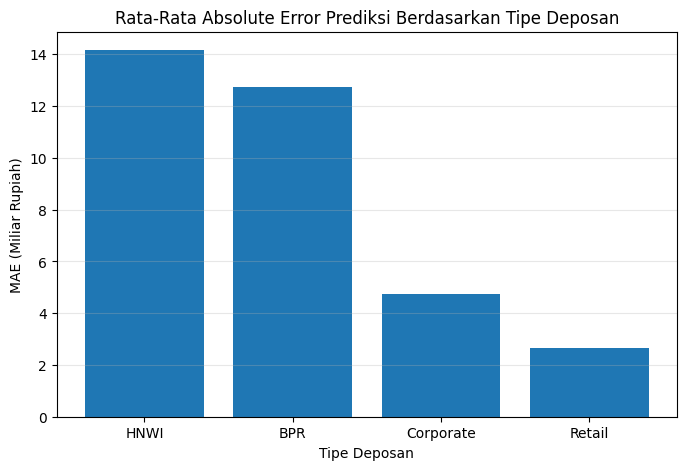

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    error_by_depositor["Type_Depositor"],
    error_by_depositor["MAE"]
)

plt.title("Rata-Rata Absolute Error Prediksi Berdasarkan Tipe Deposan")
plt.xlabel("Tipe Deposan")
plt.ylabel("MAE (Miliar Rupiah)")
plt.grid(axis="y", alpha=0.3)
plt.show()

## Interpretasi Error Prediksi Berdasarkan Tipe Deposan

Hasil analisis error menunjukkan bahwa model memiliki kesalahan prediksi terbesar pada tipe deposan HNWI dan BPR. HNWI memiliki MAE sebesar 14,17 miliar rupiah, sedangkan BPR memiliki MAE sebesar 12,73 miliar rupiah.

Kesalahan prediksi yang lebih besar pada HNWI dan BPR dapat terjadi karena kedua kelompok ini memiliki nilai deposit yang lebih besar dan lebih berpengaruh terhadap struktur deposit. Pada HNWI, rata-rata nilai aktual sebesar 74,18 miliar rupiah, sedangkan rata-rata prediksi sebesar 66,02 miliar rupiah. Hal ini menunjukkan bahwa model cenderung memprediksi HNWI lebih rendah dari nilai aktual.

Pada BPR, rata-rata nilai aktual sebesar 49,17 miliar rupiah, sedangkan rata-rata prediksi sebesar 53,70 miliar rupiah. Hal ini menunjukkan bahwa model cenderung sedikit melebihkan prediksi pada BPR.

Corporate dan Retail memiliki error yang lebih rendah. Hal ini menunjukkan bahwa pola deposit pada kedua kelompok tersebut lebih mudah diprediksi oleh model, atau memiliki nilai nominal yang lebih kecil sehingga kesalahan prediksinya juga lebih rendah.

Dalam konteks stabilitas pendanaan, hasil ini penting karena menunjukkan bahwa kelompok deposan besar seperti HNWI dan BPR tidak hanya dominan secara nilai, tetapi juga lebih sulit diprediksi. Oleh karena itu, kedua kelompok ini perlu menjadi fokus pemantauan risiko.

## Analisis Feature Importance

Setelah model terbaik diperoleh, dilakukan analisis feature importance untuk melihat fitur mana yang paling berpengaruh terhadap prediksi total deposit.

Metode yang digunakan adalah permutation importance. Metode ini bekerja dengan mengacak nilai satu fitur, lalu melihat seberapa besar performa model menurun. Jika performa model turun besar setelah suatu fitur diacak, maka fitur tersebut dianggap penting bagi model.

In [ ]:
from sklearn.inspection import permutation_importance

# Menghitung permutation importance pada model terbaik
perm_result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring="neg_root_mean_squared_error"
)

# Membuat tabel feature importance
feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_Mean": perm_result.importances_mean,
    "Importance_Std": perm_result.importances_std
}).sort_values("Importance_Mean", ascending=False)

feature_importance

,Feature,Importance_Mean,Importance_Std
4,lag_deposit_4_billion,8.737994,0.735205
5,rolling_mean_4_prev_billion,4.891834,0.521316
3,lag_deposit_1_billion,2.205730,0.386866
6,rolling_std_4_prev_billion,2.016552,0.407906
0,Type_Depositor,0.935453,0.308150
2,Month_Number,0.084259,0.096825
1,Year,0.000000,0.000000


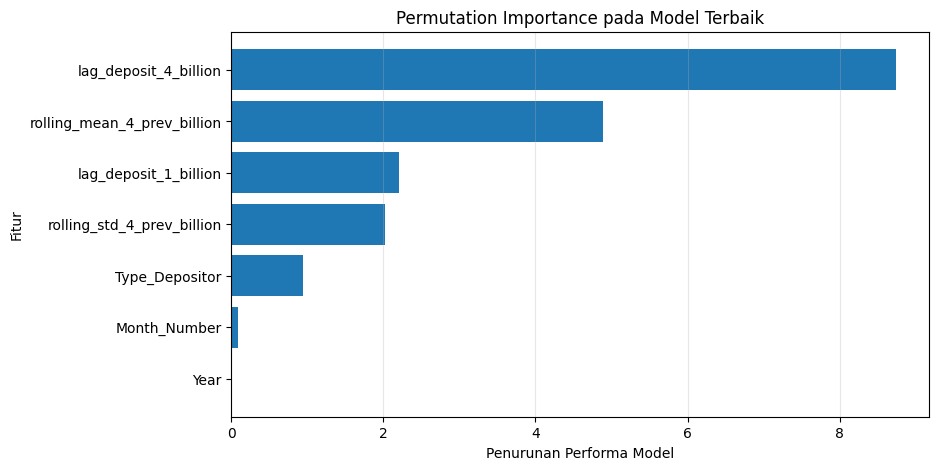

In [ ]:
plt.figure(figsize=(9, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance_Mean"]
)

plt.title("Permutation Importance pada Model Terbaik")
plt.xlabel("Penurunan Performa Model")
plt.ylabel("Fitur")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.show()

## Interpretasi Feature Importance

Hasil permutation importance menunjukkan bahwa fitur paling penting dalam prediksi total deposit adalah `lag_deposit_4_billion`. Artinya, nilai deposit empat periode sebelumnya memiliki pengaruh paling besar terhadap hasil prediksi model.

Fitur penting berikutnya adalah `rolling_mean_4_prev_billion`, yaitu rata-rata deposit pada empat periode sebelumnya. Hal ini menunjukkan bahwa model tidak hanya melihat satu periode sebelumnya, tetapi juga menangkap pola rata-rata historis dalam beberapa periode terakhir.

Fitur `lag_deposit_1_billion` dan `rolling_std_4_prev_billion` juga memiliki pengaruh terhadap prediksi. Ini berarti nilai deposit periode sebelumnya dan volatilitas deposit historis ikut membantu model dalam memperkirakan nilai deposit berikutnya.

Sementara itu, fitur `Month_Number` dan `Year` memiliki pengaruh yang sangat kecil. Hal ini menunjukkan bahwa pola deposit dalam dataset lebih banyak dijelaskan oleh perilaku historis deposit dibandingkan oleh faktor kalender sederhana.

Dalam konteks stabilitas pendanaan, hasil ini penting karena menunjukkan bahwa pemantauan pola historis deposit dapat membantu membaca potensi perubahan nilai deposit. Jika nilai deposit beberapa periode sebelumnya berubah tajam, maka kondisi tersebut dapat memengaruhi prediksi deposit pada periode berikutnya.

## Kesimpulan Sementara dari Modelling

Hasil modelling menunjukkan bahwa Linear Regression menjadi model terbaik berdasarkan nilai RMSE terendah. Model ini mampu menjelaskan sekitar 79,19 persen variasi total deposit pada data testing.

Hasil prediksi menunjukkan bahwa pola historis deposit dapat digunakan untuk memperkirakan nilai deposit, terutama melalui fitur lag deposit, rolling mean, dan rolling volatility. Namun, model masih memiliki keterbatasan dalam memprediksi lonjakan deposit yang sangat tinggi.

Analisis error menunjukkan bahwa HNWI dan BPR memiliki kesalahan prediksi paling besar. Hal ini menunjukkan bahwa dua kelompok deposan tersebut bukan hanya dominan secara nominal, tetapi juga lebih sulit diprediksi dibandingkan Corporate dan Retail.

Secara umum, hasil modelling mendukung temuan sebelumnya bahwa BPR dan HNWI perlu menjadi fokus pemantauan risiko. Kedua kelompok ini memiliki kontribusi besar terhadap deposit, berpengaruh terhadap konsentrasi dana, dan memiliki pola yang lebih menantang untuk diprediksi.

## Interpretasi Akhir Hasil Analisis

Berdasarkan seluruh tahapan analisis, ditemukan bahwa struktur deposit BPR dalam dataset tidak tersebar merata antar tipe deposan. BPR dan HNWI menjadi kelompok deposan yang paling dominan, baik dari sisi nilai total deposit maupun dari sisi frekuensi menjadi deposan terbesar pada setiap periode.

Hasil EDA menunjukkan bahwa BPR dan HNWI memiliki kontribusi deposit yang jauh lebih besar dibandingkan Corporate dan Retail. BPR memiliki total kontribusi deposit terbesar, sedangkan HNWI juga memiliki nilai deposit yang besar dan beberapa kali menjadi deposan dominan pada periode dengan konsentrasi tinggi.

Dari sisi volatilitas, BPR menunjukkan rolling volatility yang paling tinggi. Artinya, deposit dari kelompok BPR mengalami perubahan yang lebih tajam pada beberapa periode. HNWI relatif lebih stabil pada beberapa ukuran pertumbuhan, tetapi tetap penting karena nilai depositnya besar.

Hasil HHI menunjukkan bahwa deposit dalam dataset memiliki tingkat konsentrasi yang cukup tinggi. Pada beberapa periode awal, nilai HHI sangat tinggi karena deposit terkonsentrasi pada satu tipe deposan. Setelah itu, konsentrasi cenderung menurun, tetapi tetap menunjukkan adanya ketergantungan pada kelompok deposan tertentu.

Uji statistik juga menunjukkan bahwa terdapat perbedaan signifikan nilai deposit antar tipe deposan. Perbedaan ini memperkuat hasil visualisasi bahwa BPR, HNWI, Corporate, dan Retail memiliki karakteristik deposit yang tidak sama.

## Kaitan Hasil Analisis dengan Risiko Flight to Quality

Penelitian ini tidak membuktikan terjadinya flight to quality secara kausal. Dataset yang digunakan tidak memuat data perpindahan dana antarbank, data penutupan rekening, alasan deposan memindahkan dana, atau indikator kesehatan masing-masing bank.

Namun, hasil analisis dapat digunakan untuk membaca indikasi awal risiko yang berkaitan dengan flight to quality. Indikasi tersebut terlihat dari konsentrasi deposit pada kelompok deposan besar, dominasi BPR dan HNWI, serta volatilitas deposit yang cukup tinggi pada beberapa periode.

Jika dana simpanan terlalu bergantung pada kelompok deposan tertentu, maka stabilitas pendanaan dapat menjadi lebih rentan. Ketika kelompok deposan besar mengubah perilaku simpanannya, misalnya menarik dana, memindahkan dana, atau mengalihkan simpanan ke institusi yang dianggap lebih aman, maka struktur pendanaan BPR dapat ikut terdampak.

Dengan demikian, hasil penelitian ini lebih tepat dibaca sebagai analisis indikasi risiko konsentrasi dan volatilitas dana pihak ketiga. Temuan ini dapat menjadi dasar awal untuk memantau potensi risiko flight to quality, tetapi tidak boleh disimpulkan sebagai bukti langsung bahwa flight to quality benar-benar terjadi.

## Rekomendasi Kebijakan dan Manajerial

Berdasarkan hasil analisis, BPR perlu memperkuat pemantauan terhadap deposan besar, terutama kelompok BPR dan HNWI. Kedua kelompok ini memiliki kontribusi besar terhadap total deposit dan paling sering menjadi deposan dominan.

BPR juga perlu memantau volatilitas deposit secara berkala. Fitur seperti rolling volatility dapat digunakan sebagai indikator awal untuk melihat apakah nilai deposit berubah terlalu tajam dalam beberapa periode terakhir. Jika volatilitas meningkat, manajemen perlu mengevaluasi potensi tekanan likuiditas.

Selain itu, BPR perlu mengurangi ketergantungan pada satu kelompok deposan tertentu. Diversifikasi sumber dana penting agar stabilitas pendanaan tidak terlalu bergantung pada deposan besar. Peningkatan kontribusi deposan Retail dan Corporate dapat menjadi salah satu strategi untuk memperluas basis pendanaan.

Dari sisi regulator atau pengawas, hasil seperti HHI dan dominasi deposan dapat digunakan sebagai indikator pemantauan awal. Jika suatu BPR memiliki konsentrasi dana yang terlalu tinggi pada kelompok tertentu, maka pengawasan terhadap risiko likuiditas dan stabilitas pendanaan perlu ditingkatkan.

Model prediksi juga dapat digunakan sebagai alat bantu pemantauan. Meskipun model belum sempurna, hasilnya menunjukkan bahwa pola historis deposit dapat membantu memperkirakan nilai deposit periode berikutnya. Namun, model tetap perlu dilengkapi dengan analisis kualitatif dan indikator keuangan lain.

## Kesimpulan Akhir

Secara keseluruhan, penelitian ini menunjukkan bahwa perilaku simpanan deposito BPR dalam dataset memiliki pola yang tidak merata antar tipe deposan. BPR dan HNWI menjadi kelompok deposan yang paling dominan, sedangkan Corporate dan Retail memiliki nilai deposit yang lebih kecil.

Hasil analisis konsentrasi, volatilitas, uji statistik, dan modelling menunjukkan bahwa BPR dan HNWI perlu menjadi perhatian utama dalam pemantauan stabilitas pendanaan. Kedua kelompok ini memiliki peran besar terhadap struktur deposit dan memiliki potensi risiko apabila terjadi perubahan perilaku simpanan.

Penelitian ini tidak menyimpulkan bahwa flight to quality telah terjadi. Namun, hasil penelitian menunjukkan adanya indikasi risiko yang relevan dengan isu flight to quality, terutama dari sisi konsentrasi dana, volatilitas deposit, dan ketergantungan pada deposan besar.

Dengan demikian, pendekatan data science dapat membantu membaca pola perilaku deposan, mengidentifikasi risiko konsentrasi, dan mendukung pengambilan keputusan dalam menjaga stabilitas sistem perbankan, khususnya pada konteks BPR.